# Stage 11 — Development Extension Acquisition and Source Recoverability Gates

**Protocol amendment v0.2.** The original v0.1 run stopped before any Stage 11 final record was sealed because the TCIA NBIA endpoint returned an HTTP-success response whose body was not JSON. This transport repair preserves the Stage 10 role registry, scientific endpoint, representation, source gate, locked-blind firewall, and all method boundaries. It adds typed response validation and records a persistently malformed official-provider response as `HOLD_PROVIDER_TRANSPORT`, allowing the remaining preassigned development datasets to continue without substitution or mirror use.

This notebook acquires and audits only the five **development-extension** breast-ultrasound datasets prospectively assigned in Stage 10. It verifies the Stage 10 seal and role registry; obtains official archives in frozen priority order; checks licences, versions, checksums, schemas, released benign/malignant labels, patient grouping, and cross-dataset duplicates; extracts the same frozen ImageNet ResNet50 V2 representation used in Stage 8; then freezes patient-grouped source axes and applies the precommitted recoverability gate.

The three `LOCKED_BLIND_TEST` datasets remain inaccessible. Their images, labels, metadata, endpoints, archive contents, and performance are not requested or inspected. A development dataset that is inaccessible or lacks defensible labels/patient grouping is recorded as `UNAVAILABLE` or `HOLD`; it is not replaced and is not promoted by inference. Raw archives and images exist only in Colab temporary storage and are removed at completion. Drive receives only provenance ledgers, privacy-safe manifests, embeddings, duplicate audits, partitions, frozen source axes, validation records, a report, and one summary figure.

Stage 11 does **not** calculate cross-domain transfer edges, fit final DDO2 coefficients, alter the frozen Stage 9 model specification, tune a target threshold, or perform blind validation.


In [1]:
# @title 11-0. Mount Drive, verify Stage 10, seal Stage 11, and enforce the blind-data firewall
import gc
import hashlib
import importlib.metadata
import io
import json
import math
import os
import platform
import re
import shutil
import subprocess
import sys
import tarfile
import time
import warnings
import zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import quote, urljoin, urlparse

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    DEFAULT_PROJECT_ROOT = Path("/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability")
except ModuleNotFoundError:
    DEFAULT_PROJECT_ROOT = Path("/tmp/Cross-Modal_Diagnostic_Observability")

print("================ STAGE 11 DEVELOPMENT-ONLY PREFLIGHT ================")

TEST_MODE = bool(os.environ.get("CDO_STAGE11_TEST_MODE") == "1" and not IN_COLAB)
PROJECT_ROOT = Path(os.environ.get("CDO_PROJECT_ROOT", str(DEFAULT_PROJECT_ROOT)))
CODE_ROOT = PROJECT_ROOT / "05_Code" / "Cross_Modal"
CROSS_MODAL_ROOT = PROJECT_ROOT / "06_Data_Records" / "Cross_Modal"
STAGE10_ROOT = CROSS_MODAL_ROOT / "Stage10_Preassigned_Development_And_Locked_Blind_Registry_v0.1"
STAGE11_ROOT = CROSS_MODAL_ROOT / "Stage11_Development_Extension_Acquisition_And_Source_Gates_v0.2"

PROTOCOL_ROOT = STAGE11_ROOT / "00_Protocol"
ACQUISITION_ROOT = STAGE11_ROOT / "01_Official_Acquisition"
MANIFEST_ROOT = STAGE11_ROOT / "02_Harmonised_Manifests"
EMBEDDING_ROOT = STAGE11_ROOT / "03_Frozen_Embeddings"
AXIS_ROOT = STAGE11_ROOT / "04_Frozen_Source_Axes"
AUDIT_ROOT = STAGE11_ROOT / "05_Quality_And_Leakage_Audits"
RESULT_ROOT = STAGE11_ROOT / "06_Results"
for directory in [CODE_ROOT, PROTOCOL_ROOT, ACQUISITION_ROOT, MANIFEST_ROOT, EMBEDDING_ROOT, AXIS_ROOT, AUDIT_ROOT, RESULT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PATH = CODE_ROOT / "CrossModal_Stage11_Development_Extension_Acquisition_And_Source_Recoverability_Gates_v0.2.ipynb"
STAGE10_PROTOCOL_PATH = STAGE10_ROOT / "00_Protocol" / "Stage10_Acquisition_Role_Registry_Protocol_Seal_v0.1.json"
STAGE10_ENDPOINT_PATH = STAGE10_ROOT / "01_Role_Registry" / "Stage10_Frozen_Harmonised_Endpoint_Specifications_v0.1.json"
STAGE10_ROLE_PATH = STAGE10_ROOT / "01_Role_Registry" / "Stage10_Frozen_Dataset_Acquisition_Role_Registry_v0.1.csv"
STAGE10_HANDOFF_PATH = STAGE10_ROOT / "03_Development_Extension" / "Stage10_Stage11_Handoff_And_Amendment_Rules_v0.1.json"
STAGE10_MANIFEST_PATH = STAGE10_ROOT / "03_Development_Extension" / "Stage10_Stage11_Development_Only_Acquisition_Manifest_v0.1.csv"
STAGE10_SEQUENCE_PATH = STAGE10_ROOT / "03_Development_Extension" / "Stage10_Frozen_Development_Acquisition_Sequence_v0.1.csv"
STAGE10_FINAL_PATH = STAGE10_ROOT / "05_Results" / "Stage10_Preassigned_Role_Registry_Complete_v0.1.json"

PROTOCOL_SEAL_PATH = PROTOCOL_ROOT / "Stage11_Development_Acquisition_And_Source_Gate_Protocol_Seal_v0.2.json"
PARENT_COMMITMENT_PATH = PROTOCOL_ROOT / "Stage11_Stage10_Parent_Input_Commitment_v0.2.csv"
ACQUISITION_LEDGER_PATH = ACQUISITION_ROOT / "Stage11_Development_Dataset_Acquisition_Status_v0.2.csv"
OFFICIAL_FILE_LEDGER_PATH = ACQUISITION_ROOT / "Stage11_Official_File_Checksum_Ledger_v0.2.csv"
REQUEST_LOG_PATH = ACQUISITION_ROOT / "Stage11_Development_Only_Request_Audit_v0.2.csv"
SCHEMA_AUDIT_PATH = AUDIT_ROOT / "Stage11_Label_Grouping_And_Eligibility_Audit_v0.2.csv"
DUPLICATE_AUDIT_PATH = AUDIT_ROOT / "Stage11_CrossDataset_Duplicate_Audit_v0.2.csv"
VALIDATION_PATH = AUDIT_ROOT / "Stage11_Independent_Validity_Checks_v0.2.csv"
SOURCE_SUMMARY_PATH = AXIS_ROOT / "Stage11_Source_Recoverability_Summary_v0.2.csv"
PARTITION_INVENTORY_PATH = AXIS_ROOT / "Stage11_Source_Partition_Inventory_v0.2.csv"
OUTPUT_MANIFEST_PATH = RESULT_ROOT / "Stage11_Output_Integrity_Manifest_v0.2.csv"
RUNTIME_STATE_PATH = RESULT_ROOT / "Stage11_Runtime_State_v0.2.json"
FINAL_RECORD_PATH = RESULT_ROOT / "Stage11_Development_Acquisition_And_Source_Gates_Complete_v0.2.json"
REPORT_PATH = RESULT_ROOT / "Stage11_Development_Acquisition_And_Source_Gates_Report_v0.2.md"
FIGURE_PATH = RESULT_ROOT / "Stage11_Source_Recoverability_v0.2.png"

TEMP_ROOT = Path(os.environ.get("CDO_STAGE11_TEMP_ROOT", "/content/stage11_v02_tmp" if IN_COLAB else "/tmp/stage11_v02_tmp"))
TEMP_ROOT.mkdir(parents=True, exist_ok=True)

EXPECTED_STAGE10_FINAL_HASH = "6438434cb41607ad97b1b4a2fab07b143969ce7f551b87b5c2a23afbe67ccccf"
EXPECTED_STAGE10_PROTOCOL_SEAL = "305c715cd95c72b7e54cfd241891080ddd6838e4428c6bd5acdf7b4264c96f31"
EXPECTED_ROLE_REGISTRY_HASH = "cc0b56178eecee123d8c6fa99824018b18aae79679c6620edc7e5ebcc9018bc3"
EXPECTED_ENDPOINT_SPEC_HASH = "7eb31a4630c68488dac71d1602e4faf2dca348541d1a9ee62103524e8b83997c"

RANDOM_SEED = 20260721
N_BOOTSTRAP = 500
FROZEN_FEATURE_DIMENSION = 2048
EMBEDDING_BATCH_SIZE = 24
DOWNLOAD_WORKERS = 6
MAXIMUM_NEW_STAGE11_BYTES = 1024 * 1024 * 1024
AUC_MINIMUM = 0.70
AUC_CI_LOWER_STRICT_MINIMUM = 0.55

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def sha256_bytes(raw):
    return hashlib.sha256(raw).hexdigest()

def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            block = handle.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()

def sha256_json(payload):
    raw = json.dumps(payload, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()

def canonical_csv_text(frame):
    return frame.to_csv(index=False, lineterminator="\n", float_format="%.12g")

def atomic_text(path, text):
    temporary = Path(str(path) + ".tmp")
    temporary.write_text(text, encoding="utf-8")
    os.replace(temporary, path)

def atomic_json(path, payload):
    atomic_text(path, json.dumps(payload, indent=2, ensure_ascii=False) + "\n")

def write_immutable_text(path, text):
    path = Path(path)
    if path.is_file():
        assert path.read_text(encoding="utf-8") == text, f"Existing immutable output differs: {path}"
    else:
        path.write_text(text, encoding="utf-8")

def write_immutable_csv(path, frame):
    write_immutable_text(path, canonical_csv_text(frame))

def write_immutable_json(path, payload):
    write_immutable_text(path, json.dumps(payload, indent=2, ensure_ascii=False) + "\n")

def write_progress_csv(path, frame):
    text = canonical_csv_text(frame)
    if FINAL_RECORD_PATH.is_file():
        assert Path(path).is_file() and Path(path).read_text(encoding="utf-8") == text
    else:
        atomic_text(path, text)

def verify_self_hashed_json(path, hash_field, expected_hash=None):
    payload = json.loads(Path(path).read_text(encoding="utf-8"))
    claim = payload.get(hash_field)
    without_claim = dict(payload)
    without_claim.pop(hash_field, None)
    assert claim == sha256_json(without_claim), f"Self-hash mismatch: {path}"
    if expected_hash is not None:
        assert claim == expected_hash, f"Unexpected {hash_field}: {path}"
    return payload

def normalised_notebook_source_sha256(path):
    notebook = json.loads(Path(path).read_text(encoding="utf-8"))
    payload = []
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") not in {"code", "markdown"}:
            continue
        source = cell.get("source", [])
        source = "".join(source) if isinstance(source, list) else str(source)
        payload.append({"cell_type": cell["cell_type"], "source": source.replace("\r\n", "\n")})
    return sha256_json(payload)

required_parent_inputs = [
    STAGE10_PROTOCOL_PATH, STAGE10_ENDPOINT_PATH, STAGE10_ROLE_PATH, STAGE10_HANDOFF_PATH,
    STAGE10_MANIFEST_PATH, STAGE10_SEQUENCE_PATH, STAGE10_FINAL_PATH,
]
assert NOTEBOOK_PATH.is_file(), f"Open the notebook from its frozen Drive location: {NOTEBOOK_PATH}"
assert all(path.is_file() for path in required_parent_inputs), "A required Stage 10 input is missing; do not substitute a similarly named file."

stage10_final = verify_self_hashed_json(
    STAGE10_FINAL_PATH, "final_record_sha256", None if TEST_MODE else EXPECTED_STAGE10_FINAL_HASH
)
stage10_seal = verify_self_hashed_json(
    STAGE10_PROTOCOL_PATH, "seal_sha256", None if TEST_MODE else EXPECTED_STAGE10_PROTOCOL_SEAL
)
if not TEST_MODE:
    assert sha256_file(STAGE10_ROLE_PATH) == EXPECTED_ROLE_REGISTRY_HASH
    assert sha256_file(STAGE10_ENDPOINT_PATH) == EXPECTED_ENDPOINT_SPEC_HASH
assert stage10_final["decision"] == "SEAL_PREASSIGNED_DEVELOPMENT_EXTENSION_AND_LOCKED_BLIND_REGISTRY_AUTHORISE_DEVELOPMENT_ACQUISITION_ONLY"
assert stage10_final["new_images_downloaded"] is False and stage10_final["blind_validation_performed"] is False

role_registry = pd.read_csv(STAGE10_ROLE_PATH)
development_registry = role_registry[role_registry["role_frozen_before_label_access"].eq("DEVELOPMENT_EXTENSION")].copy()
blind_registry = role_registry[role_registry["role_frozen_before_label_access"].eq("LOCKED_BLIND_TEST")].copy()
assert len(development_registry) == 5 and len(blind_registry) == 3
AUTHORISED_DATASETS = tuple(development_registry.sort_values("acquisition_priority")["dataset_id"].astype(str))
PROHIBITED_DATASETS = tuple(blind_registry["dataset_id"].astype(str))
assert set(AUTHORISED_DATASETS).isdisjoint(PROHIBITED_DATASETS)

stage10_handoff = verify_self_hashed_json(STAGE10_HANDOFF_PATH, "handoff_sha256")
assert tuple(stage10_handoff["authorised_assets"]) == AUTHORISED_DATASETS
assert set(stage10_handoff["prohibited_assets"]) == set(PROHIBITED_DATASETS)

parent_commitment = pd.DataFrame([
    {"role": path.name, "relative_path": str(path.relative_to(PROJECT_ROOT)), "size_bytes": path.stat().st_size, "sha256": sha256_file(path)}
    for path in required_parent_inputs
])
write_immutable_csv(PARENT_COMMITMENT_PATH, parent_commitment)

ANALYSIS_SPEC = {
    "scope": "development-extension acquisition and patient-grouped source recoverability only",
    "authorised_datasets_in_frozen_order": list(AUTHORISED_DATASETS),
    "prohibited_locked_blind_datasets": list(PROHIBITED_DATASETS),
    "endpoint": "released benign versus malignant breast lesion; normal/unknown/missing excluded; BI-RADS alone never converted to pathology",
    "representation": "same fixed torchvision ResNet50 IMAGENET1K_V2 global-average-pooled 2048D L2 embedding as Stage 8",
    "source_probe": "StandardScaler plus class-balanced L2 logistic regression C=1 liblinear",
    "source_gate": "patient-grouped development OOF and held-out validation AUC each >=0.70 with patient-bootstrap lower 95% CI >0.55",
    "patient_rule": "all images from one released patient stay in one split; image-as-patient substitution is prohibited when grouping is unknown",
    "duplicate_rule": "cross-dataset exact decoded-pixel or identical 256-bit difference-hash matches are excluded from source fitting and retained in audit",
    "storage": "raw archives/images temporary in Colab only; Drive cap 1 GiB; frozen embeddings and audit artifacts persisted",
    "failure_policy": "UNAVAILABLE or HOLD under original development role; no mirror, substitute, blind-role transfer, or outcome-based activation",
    "transport_amendment": "v0.2 validates JSON/ZIP response types; repeated HTTP-success non-JSON from an official provider becomes HOLD_PROVIDER_TRANSPORT and cannot stop other frozen development roles",
    "method_boundary": "no transfer-edge evaluation, target refit, threshold tuning, DDO2 coefficient fit, or blind validation",
}

notebook_source_hash = normalised_notebook_source_sha256(NOTEBOOK_PATH)
seal_candidate = {
    "stage": "Stage11",
    "protocol_version": "0.2",
    "amends_unfinished_protocol_version": "0.1",
    "amendment_reason": "TCIA NBIA returned HTTP 200 with a non-JSON body; v0.1 stopped before a final Stage 11 record was sealed",
    "decision": "SEAL_DEVELOPMENT_ONLY_ACQUISITION_AND_SOURCE_RECOVERABILITY_PROTOCOL",
    "parent_stage10_final_record_sha256": stage10_final["final_record_sha256"],
    "parent_stage10_protocol_seal_sha256": stage10_seal["seal_sha256"],
    "role_registry_sha256": sha256_file(STAGE10_ROLE_PATH),
    "stage10_handoff_sha256": stage10_handoff["handoff_sha256"],
    "notebook_source_sha256": notebook_source_hash,
    "analysis_spec": ANALYSIS_SPEC,
    "analysis_spec_sha256": sha256_json(ANALYSIS_SPEC),
    "maximum_new_stage11_bytes": MAXIMUM_NEW_STAGE11_BYTES,
    "sealed_utc": utc_now(),
}
seal_candidate["seal_sha256"] = sha256_json(seal_candidate)
if PROTOCOL_SEAL_PATH.is_file():
    protocol_seal = verify_self_hashed_json(PROTOCOL_SEAL_PATH, "seal_sha256")
    assert protocol_seal["parent_stage10_final_record_sha256"] == stage10_final["final_record_sha256"]
    assert protocol_seal["notebook_source_sha256"] == notebook_source_hash
    assert protocol_seal["analysis_spec_sha256"] == seal_candidate["analysis_spec_sha256"]
else:
    write_immutable_json(PROTOCOL_SEAL_PATH, seal_candidate)
    protocol_seal = seal_candidate

REPLAY_MODE = FINAL_RECORD_PATH.is_file()
runtime_state = {
    "stage": "Stage11", "stage10_verified": True, "stage11_protocol_sealed": True,
    "authorised_development_datasets": list(AUTHORISED_DATASETS),
    "locked_blind_datasets": list(PROHIBITED_DATASETS), "locked_blind_assets_touched": False,
    "external_requests_made": False, "raw_images_copied_to_drive": False,
    "cross_domain_edges_evaluated": False, "ddo2_coefficients_fitted": False,
    "blind_validation_performed": False, "replay_mode": REPLAY_MODE, "last_updated_utc": utc_now(),
}
atomic_json(RUNTIME_STATE_PATH, runtime_state)

print("Stage 10 final record verified:", stage10_final["final_record_sha256"])
print("Stage 10 role registry verified:", sha256_file(STAGE10_ROLE_PATH))
print("Stage 11 protocol seal:", protocol_seal["seal_sha256"])
print("Authorised development / prohibited blind datasets:", len(AUTHORISED_DATASETS), "/", len(PROHIBITED_DATASETS))
print("Replay mode / locked-blind assets touched:", REPLAY_MODE, "/", False)


Mounted at /content/drive
================ STAGE 11 DEVELOPMENT-ONLY PREFLIGHT ================
Stage 10 final record verified: 6438434cb41607ad97b1b4a2fab07b143969ce7f551b87b5c2a23afbe67ccccf
Stage 10 role registry verified: cc0b56178eecee123d8c6fa99824018b18aae79679c6620edc7e5ebcc9018bc3
Stage 11 protocol seal: fc96bd4f61b41c0f64e5a24d8a270487acb25ad7c77d5b6865e9d9f4af59bbcd
Authorised development / prohibited blind datasets: 5 / 3
Replay mode / locked-blind assets touched: False / False


In [2]:
# @title 11-1. Acquire only the five frozen development datasets from official repositories
if not REPLAY_MODE and not TEST_MODE:
    required_packages = []
    for module_name, package_name in [
        ("pydicom", "pydicom"), ("openpyxl", "openpyxl"), ("py7zr", "py7zr"),
        ("pylibjpeg", "pylibjpeg"), ("libjpeg", "pylibjpeg-libjpeg"),
    ]:
        try:
            __import__(module_name)
        except ModuleNotFoundError:
            required_packages.append(package_name)
    if required_packages:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required_packages])

if TEST_MODE:
    requests = None
else:
    import requests

class PermanentAccessError(RuntimeError):
    pass

class RetryableAccessError(RuntimeError):
    pass

class SchemaHoldError(RuntimeError):
    pass

class ProviderTransportHoldError(RuntimeError):
    pass

REQUEST_AUDIT = []
OFFICIAL_FILE_ROWS = []
acquisition_assets = {}
retryable_failures = []

development_manifest_plan = pd.read_csv(STAGE10_MANIFEST_PATH).sort_values("acquisition_priority")
assert tuple(development_manifest_plan["dataset_id"].astype(str)) == AUTHORISED_DATASETS
forbidden_tokens = {
    str(value).lower()
    for column in ["dataset_id", "persistent_id", "official_landing_url"]
    for value in blind_registry[column].dropna().astype(str)
}

SESSION = None if TEST_MODE else requests.Session()
if SESSION is not None:
    SESSION.headers.update({
        "User-Agent": "Mozilla/5.0 (compatible; CDO-Stage11/0.2; public-research-acquisition)",
        "Accept": "*/*",
    })

def assert_development_request(dataset_id, url):
    assert dataset_id in AUTHORISED_DATASETS, f"Network request is not assigned to a development dataset: {dataset_id}"
    lowered = str(url).lower()
    assert not any(token and token in lowered for token in forbidden_tokens), "Locked-blind URL/token request blocked."
    assert urlparse(str(url)).scheme in {"http", "https"}

def guarded_get(dataset_id, url, *, stream=False, timeout=(20, 180), attempts=4, allow_status=(), headers=None):
    assert_development_request(dataset_id, url)
    last = None
    for attempt in range(1, attempts + 1):
        started = time.time()
        try:
            response = SESSION.get(url, stream=stream, timeout=timeout, allow_redirects=True, headers=headers)
            status = int(response.status_code)
            REQUEST_AUDIT.append({
                "dataset_id": dataset_id, "request_url": str(url), "resolved_host": urlparse(response.url).netloc,
                "status_code": status, "attempt": attempt, "elapsed_seconds": time.time() - started,
                "content_type": str(response.headers.get("Content-Type", "")),
                "content_length_header": str(response.headers.get("Content-Length", "")),
                "response_validation": "HTTP_STATUS_ONLY",
                "locked_blind_request": False,
            })
            if status in allow_status:
                return response
            if status in {401, 403, 404, 410}:
                raise PermanentAccessError(f"HTTP {status}: {url}")
            if status == 429 or status >= 500:
                raise RetryableAccessError(f"HTTP {status}: {url}")
            response.raise_for_status()
            return response
        except PermanentAccessError:
            raise
        except (requests.Timeout, requests.ConnectionError, RetryableAccessError) as exc:
            last = exc
            if attempt < attempts:
                time.sleep(min(8, 2 ** (attempt - 1)))
                continue
            raise RetryableAccessError(str(last))
    raise RetryableAccessError(str(last))

def guarded_json(dataset_id, url, *, timeout=(20, 180), attempts=4):
    """Require a real JSON response; HTTP 200 with HTML/text is a typed transport failure."""
    last = None
    for parse_attempt in range(1, attempts + 1):
        response = guarded_get(
            dataset_id, url, timeout=timeout, attempts=1,
            headers={"Accept": "application/json, text/json;q=0.9"},
        )
        content_type = str(response.headers.get("Content-Type", "")).lower()
        try:
            payload = response.json()
            if REQUEST_AUDIT:
                REQUEST_AUDIT[-1]["response_validation"] = "VALID_JSON"
            return payload
        except (ValueError, requests.exceptions.JSONDecodeError) as exc:
            sample = re.sub(r"\s+", " ", response.text[:240]).strip()
            last = f"non-JSON response (content-type={content_type or 'missing'}, sample={sample!r})"
            if REQUEST_AUDIT:
                REQUEST_AUDIT[-1]["response_validation"] = "INVALID_JSON_BODY"
                REQUEST_AUDIT[-1]["response_body_prefix_sha256"] = sha256_bytes(response.content[:4096])
            if parse_attempt < attempts:
                time.sleep(min(8, 2 ** (parse_attempt - 1)))
                continue
            raise RetryableAccessError(f"Expected JSON from {url}; {last}") from exc
    raise RetryableAccessError(f"Expected JSON from {url}; {last}")

def download_file(dataset_id, url, destination, expected_size=None, checksum_type=None, checksum_value=None):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.is_file() and expected_size is not None and destination.stat().st_size == int(expected_size):
        pass
    else:
        response = guarded_get(dataset_id, url, stream=True, timeout=(20, 300))
        temporary = Path(str(destination) + ".part")
        with temporary.open("wb") as handle:
            for block in response.iter_content(chunk_size=1024 * 1024):
                if block:
                    handle.write(block)
        os.replace(temporary, destination)
    if expected_size not in (None, "", -1):
        assert destination.stat().st_size == int(expected_size), f"Size mismatch: {destination.name}"
    actual_sha256 = sha256_file(destination)
    if checksum_value:
        kind = str(checksum_type or "").lower()
        if kind == "md5":
            actual = hashlib.md5(destination.read_bytes()).hexdigest()
        elif kind in {"sha256", "sha-256"}:
            actual = actual_sha256
        else:
            actual = ""
        if actual:
            assert actual.lower() == str(checksum_value).lower(), f"Checksum mismatch: {destination.name}"
    OFFICIAL_FILE_ROWS.append({
        "dataset_id": dataset_id, "official_filename": destination.name,
        "download_url_host": urlparse(str(url)).netloc, "size_bytes": destination.stat().st_size,
        "repository_checksum_type": str(checksum_type or ""),
        "repository_checksum": str(checksum_value or ""), "download_sha256": actual_sha256,
    })
    return destination

def safe_target(root, member_name):
    root = Path(root).resolve()
    target = (root / member_name).resolve()
    assert target == root or root in target.parents, f"Unsafe archive member: {member_name}"
    return target

def extract_archive(path, destination):
    path, destination = Path(path), Path(destination)
    destination.mkdir(parents=True, exist_ok=True)
    suffix = path.name.lower()
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as archive:
            for member in archive.infolist():
                safe_target(destination, member.filename)
            archive.extractall(destination)
        return True
    if tarfile.is_tarfile(path):
        with tarfile.open(path) as archive:
            for member in archive.getmembers():
                safe_target(destination, member.name)
            archive.extractall(destination, filter="data")
        return True
    if suffix.endswith(".7z"):
        import py7zr
        with py7zr.SevenZipFile(path, mode="r") as archive:
            for name in archive.getnames():
                safe_target(destination, name)
            archive.extractall(destination)
        return True
    return False

def recursively_extract(root):
    root = Path(root)
    processed = set()
    for _ in range(4):
        candidates = [p for p in root.rglob("*") if p.is_file() and p not in processed]
        expanded = 0
        for path in candidates:
            processed.add(path)
            if path.suffix.lower() in {".zip", ".7z", ".tar", ".gz", ".tgz", ".bz2", ".xz"}:
                destination = path.parent / f"{path.stem}_extracted"
                try:
                    if extract_archive(path, destination):
                        expanded += 1
                except Exception as exc:
                    print("Archive extraction warning:", path.name, exc)
        if expanded == 0:
            break
    return root

def acquire_zenodo(dataset_id, record_id):
    root = TEMP_ROOT / dataset_id
    root.mkdir(parents=True, exist_ok=True)
    metadata = guarded_json(dataset_id, f"https://zenodo.org/api/records/{record_id}")
    assert str(metadata.get("id")) == str(record_id)
    files = metadata.get("files", [])
    if not files:
        raise SchemaHoldError("Zenodo record exposes no files")
    for entry in files:
        filename = entry.get("key") or entry.get("filename")
        links = entry.get("links", {})
        url = links.get("content") or links.get("self")
        checksum = str(entry.get("checksum", ""))
        checksum_type, checksum_value = (checksum.split(":", 1) + [""])[:2] if ":" in checksum else ("", "")
        download_file(dataset_id, url, root / filename, entry.get("size"), checksum_type, checksum_value)
    recursively_extract(root)
    metadata_block = metadata.get("metadata", {})
    licence = metadata_block.get("license") or metadata_block.get("rights") or ""
    if isinstance(licence, dict):
        licence = licence.get("id") or licence.get("title") or licence.get("name") or json.dumps(licence, sort_keys=True)
    return {"root": root, "official_version": str(metadata_block.get("version", "1.0")), "provider": "Zenodo", "official_license": str(licence)}

def acquire_mendeley(dataset_id, mendeley_id, version):
    root = TEMP_ROOT / dataset_id
    root.mkdir(parents=True, exist_ok=True)
    metadata_url = f"https://api.data.mendeley.com/datasets/{mendeley_id}/versions/{version}"
    try:
        dataset_metadata = guarded_json(dataset_id, metadata_url)
    except Exception as exc:
        print("Mendeley version-metadata warning:", dataset_id, exc)
        dataset_metadata = {}
    api_url = f"https://api.data.mendeley.com/datasets/{mendeley_id}/versions/{version}/files"
    payload = guarded_json(dataset_id, api_url)
    files = payload.get("entries", payload.get("files", [])) if isinstance(payload, dict) else payload
    if not files:
        raise SchemaHoldError("Mendeley API exposes no files")
    for entry in files:
        details = entry.get("content_details") or {}
        filename = entry.get("filename") or entry.get("name") or str(entry.get("id"))
        url = entry.get("download_url") or entry.get("downloadUrl") or (entry.get("links") or {}).get("download")
        if not url and entry.get("id"):
            url = f"https://data.mendeley.com/public-files/datasets/{mendeley_id}/files/{entry['id']}/file_downloaded"
        if not url:
            raise SchemaHoldError(f"No public download URL for {filename}")
        checksum = details.get("sha256_hash") or details.get("sha256") or entry.get("sha256_hash")
        size = details.get("size") or entry.get("size")
        download_file(dataset_id, url, root / filename, size, "sha256" if checksum else "", checksum)
    recursively_extract(root)
    licence = dataset_metadata.get("licence") or dataset_metadata.get("license") or ""
    if isinstance(licence, dict):
        licence = licence.get("name") or licence.get("id") or licence.get("title") or json.dumps(licence, sort_keys=True)
    observed_version = dataset_metadata.get("version") or version
    return {"root": root, "official_version": str(observed_version), "provider": "Mendeley Data", "official_license": str(licence)}

def discover_tcia_clinical_file(dataset_id, root):
    landing = "https://www.cancerimagingarchive.net/collection/breast-lesions-usg/"
    candidates = []
    try:
        response = guarded_get(dataset_id, landing)
        html = response.text
        candidates.extend(urljoin(landing, href) for href in re.findall(r'href=["\']([^"\']+)["\']', html, flags=re.I)
                          if re.search(r'clinical|\.xlsx(?:$|\?)|\.csv(?:$|\?)', href, flags=re.I))
    except Exception as exc:
        print("TCIA landing-page discovery warning:", exc)
    candidates.extend([
        "https://www.cancerimagingarchive.net/wp-content/uploads/BrEaST-Lesions-USG-clinical-data-Dec-15-2023.xlsx",
        "https://www.cancerimagingarchive.net/wp-content/uploads/BrEaST-Lesions-USG-clinical-data-Dec-15-2023-1.xlsx",
    ])
    seen = set()
    for url in candidates:
        if url in seen or urlparse(url).netloc not in {"www.cancerimagingarchive.net", "cancerimagingarchive.net"}:
            continue
        seen.add(url)
        try:
            filename = Path(urlparse(url).path).name or "clinical_data.xlsx"
            path = download_file(dataset_id, url, root / filename)
            if path.stat().st_size > 1000 and path.suffix.lower() in {".xlsx", ".xls", ".csv"}:
                return path
        except PermanentAccessError:
            continue
    raise SchemaHoldError("Official TCIA clinical label table could not be resolved")

def acquire_tcia(dataset_id):
    root = TEMP_ROOT / dataset_id
    root.mkdir(parents=True, exist_ok=True)
    clinical_path = discover_tcia_clinical_file(dataset_id, root)
    base = "https://services.cancerimagingarchive.net/nbia-api/services/v1"
    series = None
    inventory_errors = []
    inventory_urls = [
        f"{base}/getSeries?Collection=Breast-Lesions-USG&Modality=US&format=json",
        f"{base}/getSeries?Collection=Breast-Lesions-USG&format=json",
    ]
    for inventory_url in inventory_urls:
        try:
            candidate = guarded_json(dataset_id, inventory_url, attempts=3)
            if isinstance(candidate, list):
                series = candidate
                break
            inventory_errors.append(f"unexpected JSON type {type(candidate).__name__}: {inventory_url}")
        except (RetryableAccessError, PermanentAccessError) as exc:
            inventory_errors.append(str(exc))
    if series is None:
        raise ProviderTransportHoldError(
            "TCIA official NBIA inventory did not yield JSON after typed retries; "
            f"the preassigned dataset remains HOLD without mirror substitution. Examples={inventory_errors[:2]}"
        )
    if not isinstance(series, list) or len(series) < 200:
        raise SchemaHoldError(f"Unexpected TCIA series inventory: {len(series) if isinstance(series, list) else type(series)}")
    series = [row for row in series if str(row.get("Modality", row.get("modality", "US"))).upper() in {"US", ""}]
    dicom_root = root / "dicom"
    dicom_root.mkdir(exist_ok=True)

    def fetch_series(row):
        uid = str(row.get("SeriesInstanceUID") or row.get("seriesInstanceUid"))
        if not uid:
            return False
        token = hashlib.sha256(uid.encode()).hexdigest()[:20]
        archive = root / "series_archives" / f"{token}.zip"
        url = f"{base}/getImage?SeriesInstanceUID={quote(uid, safe='')}&format=zip"
        download_file(dataset_id, url, archive)
        if not zipfile.is_zipfile(archive):
            raise RetryableAccessError(f"TCIA getImage returned a non-ZIP body for series token {token}")
        assert extract_archive(archive, dicom_root / token)
        return True

    completed = 0
    failures = []
    with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as pool:
        futures = {pool.submit(fetch_series, row): row for row in series}
        for future in as_completed(futures):
            try:
                completed += int(bool(future.result()))
            except Exception as exc:
                failures.append(str(exc))
    if completed < max(200, int(0.95 * len(series))):
        raise RetryableAccessError(f"TCIA series incomplete: {completed}/{len(series)}; examples={failures[:3]}")
    return {"root": root, "official_version": "TCIA Breast-Lesions-USG current frozen response", "provider": "The Cancer Imaging Archive", "clinical_path": clinical_path, "official_license": "CC BY 4.0"}

def make_test_assets():
    from PIL import Image
    assets = {}
    for dataset_index, dataset_id in enumerate(AUTHORISED_DATASETS):
        root = TEMP_ROOT / dataset_id
        root.mkdir(parents=True, exist_ok=True)
        rows = []
        group_count = 30
        for group in range(group_count):
            label = group % 2
            for view in range(2):
                folder = root / ("malignant" if label else "benign")
                folder.mkdir(exist_ok=True)
                rng = np.random.default_rng(RANDOM_SEED + dataset_index * 1000 + group * 10 + view)
                base = 185 if label else 55
                array = np.clip(base + rng.normal(0, 18, size=(128, 128)), 0, 255).astype(np.uint8)
                array[:, (15 + group) % 80:(22 + group) % 90] = 250 if label else 5
                path = folder / f"patient_{group:03d}_view_{view}.png"
                Image.fromarray(array).save(path)
                rows.append({"filename": path.name, "patient_id": f"patient_{group:03d}", "diagnosis": "malignant" if label else "benign"})
        pd.DataFrame(rows).to_csv(root / "released_metadata.csv", index=False)
        assets[dataset_id] = {"root": root, "official_version": "TEST_FIXTURE", "provider": "TEST_FIXTURE", "official_license": "TEST_FIXTURE"}
    return assets

if REPLAY_MODE:
    acquisition_ledger = pd.read_csv(ACQUISITION_LEDGER_PATH)
    official_file_ledger = pd.read_csv(OFFICIAL_FILE_LEDGER_PATH)
    request_audit = pd.read_csv(REQUEST_LOG_PATH)
    print("Replay mode: official repositories are not requested again.")
else:
    if TEST_MODE:
        acquisition_assets = make_test_assets()
        for dataset_id in AUTHORISED_DATASETS:
            OFFICIAL_FILE_ROWS.append({"dataset_id": dataset_id, "official_filename": "TEST_FIXTURE", "download_url_host": "", "size_bytes": 0,
                                       "repository_checksum_type": "", "repository_checksum": "", "download_sha256": "TEST_FIXTURE"})
    else:
        for row in development_manifest_plan.itertuples(index=False):
            dataset_id = str(row.dataset_id)
            print(f"Acquiring {int(row.acquisition_priority)}/5: {dataset_id}")
            try:
                if dataset_id == "BUS_BRA_2024":
                    acquisition_assets[dataset_id] = acquire_zenodo(dataset_id, "8231412")
                elif dataset_id == "BUSI_WHU_2025_V3":
                    acquisition_assets[dataset_id] = acquire_mendeley(dataset_id, "k6cpmwybk3", 3)
                elif dataset_id == "BREAST_LESIONS_USG_2024":
                    acquisition_assets[dataset_id] = acquire_tcia(dataset_id)
                elif dataset_id == "BUS_UCLM_2025_V3":
                    acquisition_assets[dataset_id] = acquire_mendeley(dataset_id, "7fvgj4jsp7", 3)
                elif dataset_id == "RODRIGUES_BUI_2017":
                    acquisition_assets[dataset_id] = acquire_mendeley(dataset_id, "wmy84gzngw", 1)
            except SchemaHoldError as exc:
                acquisition_assets[dataset_id] = {"root": None, "provider": "official repository", "official_version": "", "pre_status": "HOLD_SCHEMA", "error": str(exc)}
            except ProviderTransportHoldError as exc:
                acquisition_assets[dataset_id] = {"root": None, "provider": "The Cancer Imaging Archive", "official_version": "", "pre_status": "HOLD_PROVIDER_TRANSPORT", "error": str(exc)}
            except PermanentAccessError as exc:
                acquisition_assets[dataset_id] = {"root": None, "provider": "official repository", "official_version": "", "pre_status": "UNAVAILABLE", "error": str(exc)}
            except RetryableAccessError as exc:
                retryable_failures.append({"dataset_id": dataset_id, "error": str(exc)})

    if retryable_failures:
        request_audit = pd.DataFrame(REQUEST_AUDIT)
        write_progress_csv(REQUEST_LOG_PATH, request_audit)
        runtime_state.update({"external_requests_made": bool(len(REQUEST_AUDIT)), "retry_required": True,
                              "retryable_failures": retryable_failures, "last_updated_utc": utc_now()})
        atomic_json(RUNTIME_STATE_PATH, runtime_state)
        raise RuntimeError(f"Retryable acquisition failure before sealing: {retryable_failures}. Rerun all; no source axis was frozen.")

    acquisition_rows = []
    for row in development_manifest_plan.itertuples(index=False):
        asset = acquisition_assets.get(str(row.dataset_id), {})
        expected_license = str(row.license)
        observed_license = str(asset.get("official_license", ""))
        expected_normalised = normalise_token(expected_license) if "normalise_token" in globals() else re.sub(r"[^a-z0-9]+", "", expected_license.lower())
        observed_normalised = normalise_token(observed_license) if "normalise_token" in globals() else re.sub(r"[^a-z0-9]+", "", observed_license.lower())
        if TEST_MODE:
            license_status = "TEST_FIXTURE"
        elif not observed_normalised:
            license_status = "OFFICIAL_LICENSE_NOT_RETURNED_REVIEW_REQUIRED"
        elif expected_normalised == observed_normalised or expected_normalised in observed_normalised or observed_normalised in expected_normalised:
            license_status = "MATCHES_FROZEN_REGISTRY"
        else:
            license_status = "OFFICIAL_METADATA_DIFFERS_FROM_FROZEN_REGISTRY_REVIEW_REQUIRED"
        acquisition_rows.append({
            "acquisition_priority": int(row.acquisition_priority), "dataset_id": str(row.dataset_id),
            "role": "DEVELOPMENT_EXTENSION", "official_landing_url": str(row.official_landing_url),
            "persistent_id": str(row.persistent_id), "provider": asset.get("provider", ""),
            "official_version_observed": asset.get("official_version", ""),
            "stage10_frozen_license": expected_license, "official_license_observed": observed_license,
            "license_verification_status": license_status,
            "acquisition_status": asset.get("pre_status", "ACQUIRED_PENDING_SCHEMA_GATE"),
            "acquisition_error": asset.get("error", ""),
            "locked_blind_asset": False, "raw_data_location": "COLAB_TEMP_ONLY",
        })
    acquisition_ledger = pd.DataFrame(acquisition_rows)
    official_file_ledger = pd.DataFrame(OFFICIAL_FILE_ROWS, columns=[
        "dataset_id", "official_filename", "download_url_host", "size_bytes", "repository_checksum_type", "repository_checksum", "download_sha256"
    ]).sort_values(["dataset_id", "official_filename"]).reset_index(drop=True)
    request_audit = pd.DataFrame(REQUEST_AUDIT, columns=[
        "dataset_id", "request_url", "resolved_host", "status_code", "attempt", "elapsed_seconds", "locked_blind_request"
    ])
    write_progress_csv(ACQUISITION_LEDGER_PATH, acquisition_ledger)
    write_progress_csv(OFFICIAL_FILE_LEDGER_PATH, official_file_ledger)
    write_progress_csv(REQUEST_LOG_PATH, request_audit)

runtime_state.update({"external_requests_made": bool(len(request_audit)), "official_development_assets_acquired": sorted(acquisition_assets),
                      "locked_blind_assets_touched": False, "last_updated_utc": utc_now()})
atomic_json(RUNTIME_STATE_PATH, runtime_state)
display(acquisition_ledger)


Acquiring 1/5: BUS_BRA_2024
Acquiring 2/5: BUSI_WHU_2025_V3
Mendeley version-metadata warning: BUSI_WHU_2025_V3 HTTP 403: https://api.data.mendeley.com/datasets/k6cpmwybk3/versions/3
Acquiring 3/5: BREAST_LESIONS_USG_2024
Acquiring 4/5: BUS_UCLM_2025_V3
Mendeley version-metadata warning: BUS_UCLM_2025_V3 HTTP 403: https://api.data.mendeley.com/datasets/7fvgj4jsp7/versions/3
Acquiring 5/5: RODRIGUES_BUI_2017
Mendeley version-metadata warning: RODRIGUES_BUI_2017 HTTP 403: https://api.data.mendeley.com/datasets/wmy84gzngw/versions/1


,acquisition_priority,dataset_id,role,official_landing_url,persistent_id,provider,official_version_observed,stage10_frozen_license,official_license_observed,license_verification_status,acquisition_status,acquisition_error,locked_blind_asset,raw_data_location
0,1,BUS_BRA_2024,DEVELOPMENT_EXTENSION,https://zenodo.org/records/8231412,10.5281/zenodo.8231412,Zenodo,1.0,CC BY 4.0,cc-by-4.0,MATCHES_FROZEN_REGISTRY,ACQUIRED_PENDING_SCHEMA_GATE,,False,COLAB_TEMP_ONLY
1,2,BUSI_WHU_2025_V3,DEVELOPMENT_EXTENSION,https://data.mendeley.com/datasets/k6cpmwybk3/3,10.17632/k6cpmwybk3.3,official repository,,CC BY 4.0,,OFFICIAL_LICENSE_NOT_RETURNED_REVIEW_REQUIRED,UNAVAILABLE,HTTP 403: https://api.data.mendeley.com/datase...,False,COLAB_TEMP_ONLY
2,3,BREAST_LESIONS_USG_2024,DEVELOPMENT_EXTENSION,https://www.cancerimagingarchive.net/collectio...,10.7937/9WKK-Q141,The Cancer Imaging Archive,,CC BY 4.0,,OFFICIAL_LICENSE_NOT_RETURNED_REVIEW_REQUIRED,HOLD_PROVIDER_TRANSPORT,TCIA official NBIA inventory did not yield JSO...,False,COLAB_TEMP_ONLY
3,4,BUS_UCLM_2025_V3,DEVELOPMENT_EXTENSION,https://data.mendeley.com/datasets/7fvgj4jsp7/3,10.17632/7fvgj4jsp7.3,official repository,,CC BY-NC 3.0,,OFFICIAL_LICENSE_NOT_RETURNED_REVIEW_REQUIRED,UNAVAILABLE,HTTP 403: https://api.data.mendeley.com/datase...,False,COLAB_TEMP_ONLY
4,5,RODRIGUES_BUI_2017,DEVELOPMENT_EXTENSION,https://data.mendeley.com/datasets/wmy84gzngw/1,10.17632/wmy84gzngw.1,official repository,,CC BY 4.0,,OFFICIAL_LICENSE_NOT_RETURNED_REVIEW_REQUIRED,UNAVAILABLE,HTTP 403: https://api.data.mendeley.com/datase...,False,COLAB_TEMP_ONLY


In [3]:
# @title 11-2. Harmonise released diagnoses and prove patient-level grouping without surrogate labels
IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
MANIFEST_COLUMNS = [
    "dataset_id", "modality", "task", "image_id", "unit_id", "group_id", "label",
    "label_basis", "patient_grouping_proven", "source_member", "source_kind", "local_path",
]

def normalise_token(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).lower())

def numeric_token(value):
    groups = re.findall(r"\d+", str(value))
    return "".join(groups)

def map_binary_label(value):
    text = re.sub(r"[_\-]+", " ", str(value).strip().lower())
    if not text or text in {"nan", "none", "na", "n/a", "unknown"}:
        return None
    if any(token in text for token in ["benign", "non malignant", "nonmalignant", "negative"]):
        return 0
    if any(token in text for token in ["malignant", "carcinoma", "cancer", "positive"]):
        return 1
    if text in {"0", "b"}:
        return 0
    if text in {"1", "m"}:
        return 1
    return None

def is_mask_path(path):
    parts = [re.sub(r"[^a-z0-9]+", " ", part.lower()).strip() for part in Path(path).parts]
    stem = re.sub(r"[^a-z0-9]+", " ", Path(path).stem.lower()).strip()
    tokens = set((" ".join(parts) + " " + stem).split())
    return bool(tokens & {"mask", "masks", "seg", "segmentation", "segmentations", "groundtruth", "ground", "gt", "labelmap", "annotation"})

def read_released_tables(root):
    tables = []
    for path in sorted(Path(root).rglob("*")):
        if not path.is_file():
            continue
        try:
            if path.suffix.lower() == ".csv":
                frame = pd.read_csv(path, low_memory=False)
            elif path.suffix.lower() in {".xlsx", ".xls"}:
                workbook = pd.ExcelFile(path)
                for sheet in workbook.sheet_names:
                    frame = pd.read_excel(path, sheet_name=sheet)
                    if len(frame):
                        tables.append((Path(f"{path}::{sheet}"), frame))
                continue
            else:
                continue
            if len(frame):
                tables.append((path, frame))
        except Exception as exc:
            print("Released table read warning:", path.name, exc)
    return tables

def column_binary_coverage(series):
    mapped = series.map(map_binary_label)
    return float(mapped.notna().mean()), int(mapped.dropna().nunique())

def choose_label_column(frame):
    preferred = []
    for column in frame.columns:
        name = normalise_token(column)
        coverage, classes = column_binary_coverage(frame[column])
        score = coverage + (1.5 if re.search(r"patholog|diagnos|histolog|malignan|benign|class|label", name) else 0)
        if coverage >= 0.30 and classes == 2:
            preferred.append((score, str(column)))
    return max(preferred)[1] if preferred else None

def choose_patient_column(frame):
    candidates = []
    for column in frame.columns:
        name = normalise_token(column)
        if re.search(r"patient|subject|caseid|patientid|idpatient|paciente", name):
            nonnull = frame[column].dropna().astype(str)
            if len(nonnull) and nonnull.nunique() >= 4:
                candidates.append((2 if "patient" in name or "subject" in name else 1, str(column)))
    return max(candidates)[1] if candidates else None

def choose_image_column(frame, image_paths):
    image_keys = {normalise_token(p.stem) for p in image_paths} | {numeric_token(p.stem) for p in image_paths if numeric_token(p.stem)}
    candidates = []
    for column in frame.columns:
        name = normalise_token(column)
        if not re.search(r"image|file|filename|imagename|scan|id", name):
            continue
        values = frame[column].dropna().astype(str)
        if not len(values):
            continue
        keys = {normalise_token(Path(v).stem) for v in values} | {numeric_token(Path(v).stem) for v in values if numeric_token(v)}
        overlap = len(image_keys & keys) / max(1, min(len(image_keys), len(keys)))
        candidates.append((overlap + (0.2 if re.search(r"image|file|scan", name) else 0), str(column)))
    return max(candidates)[1] if candidates and max(candidates)[0] > 0.05 else None

def build_metadata_lookup(root, image_paths):
    best = None
    for table_path, frame in read_released_tables(root):
        label_column = choose_label_column(frame)
        if label_column is None:
            continue
        image_column = choose_image_column(frame, image_paths)
        patient_column = choose_patient_column(frame)
        if image_column is None:
            continue
        mapped = frame[label_column].map(map_binary_label)
        valid = frame.loc[mapped.notna()].copy()
        valid["__label"] = mapped[mapped.notna()].astype(int)
        lookup = {}
        for _, row in valid.iterrows():
            value = str(row[image_column])
            keys = {normalise_token(Path(value).stem)}
            if numeric_token(value):
                keys.add(numeric_token(value))
            for key in keys:
                if key:
                    lookup[key] = {
                        "label": int(row["__label"]),
                        "group_id": str(row[patient_column]) if patient_column and pd.notna(row[patient_column]) else "",
                        "label_basis": f"released_table:{Path(str(table_path).split('::')[0]).name}:{label_column}",
                        "patient_column": patient_column or "",
                    }
        score = len(lookup) + (100000 if patient_column else 0)
        if best is None or score > best[0]:
            best = (score, lookup, str(table_path), label_column, patient_column)
    return best

def label_from_path(path):
    text = " ".join(Path(path).parts).lower()
    return map_binary_label(text)

def group_from_path(path, root):
    relative = Path(path).relative_to(root)
    for part in relative.parts[:-1]:
        if re.search(r"(?:patient|subject|case|study|scan|paciente)[_\- ]*\d+", part, flags=re.I):
            return normalise_token(part), True, "released_patient_or_case_directory"
    stem = relative.stem
    match = re.search(r"((?:patient|subject|case|study|scan|p)[_\- ]*\d+)", stem, flags=re.I)
    if match:
        return normalise_token(match.group(1)), True, "released_patient_or_case_filename"
    return normalise_token(stem), False, "image_id_only_not_patient_proven"

def generic_manifest(dataset_id, root):
    root = Path(root)
    images = [p for p in sorted(root.rglob("*")) if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES and not is_mask_path(p)]
    metadata = build_metadata_lookup(root, images)
    lookup = metadata[1] if metadata else {}
    rows = []
    for path in images:
        keys = [normalise_token(path.stem), numeric_token(path.stem)]
        record = next((lookup[key] for key in keys if key and key in lookup), None)
        if record:
            label = record["label"]
            if record["group_id"]:
                group_id, proven, group_basis = normalise_token(record["group_id"]), True, "released_patient_column"
            else:
                group_id, proven, group_basis = group_from_path(path, root)
            label_basis = record["label_basis"]
        else:
            label = label_from_path(path)
            if label is None:
                continue
            group_id, proven, group_basis = group_from_path(path, root)
            label_basis = "released_benign_or_malignant_archive_path"
        image_id = f"{dataset_id}_{sha256_bytes(str(path.relative_to(root)).encode())[:20]}"
        rows.append({
            "dataset_id": dataset_id, "modality": "breast_ultrasound", "task": "breast_lesion_malignant_vs_benign",
            "image_id": image_id, "unit_id": image_id, "group_id": group_id, "label": int(label),
            "label_basis": label_basis, "patient_grouping_proven": bool(proven),
            "group_basis": group_basis, "source_member": str(path.relative_to(root)), "source_kind": "official_archive_member",
            "local_path": str(path),
        })
    return pd.DataFrame(rows, columns=MANIFEST_COLUMNS + ["group_basis"])

def mask_label(mask_path):
    from PIL import Image
    array = np.asarray(Image.open(mask_path).convert("RGB"), dtype=np.int16)
    red = int(np.sum((array[..., 0] > 120) & (array[..., 0] > array[..., 1] + 35) & (array[..., 0] > array[..., 2] + 35)))
    green = int(np.sum((array[..., 1] > 100) & (array[..., 1] > array[..., 0] + 25) & (array[..., 1] > array[..., 2] + 25)))
    if red > 20 and red > green:
        return 1
    if green > 20 and green > red:
        return 0
    return None

def uclm_manifest(dataset_id, root):
    root = Path(root)
    all_images = [p for p in sorted(root.rglob("*")) if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES]
    masks = [p for p in all_images if is_mask_path(p)]
    images = [p for p in all_images if p not in masks]
    if not masks or not images:
        return generic_manifest(dataset_id, root)
    mask_lookup = {}
    for path in masks:
        keys = {normalise_token(path.stem.replace("mask", "").replace("segmentation", "").replace("gt", "")), numeric_token(path.stem)}
        for key in keys:
            if key:
                mask_lookup.setdefault(key, []).append(path)
    rows = []
    for path in images:
        keys = [normalise_token(path.stem), numeric_token(path.stem)]
        matches = []
        for key in keys:
            matches.extend(mask_lookup.get(key, []))
        matches = sorted(set(matches))
        if not matches:
            continue
        labels = [mask_label(mask) for mask in matches]
        labels = [label for label in labels if label is not None]
        if not labels or len(set(labels)) != 1:
            continue
        group_id, proven, group_basis = group_from_path(path, root)
        image_id = f"{dataset_id}_{sha256_bytes(str(path.relative_to(root)).encode())[:20]}"
        rows.append({
            "dataset_id": dataset_id, "modality": "breast_ultrasound", "task": "breast_lesion_malignant_vs_benign",
            "image_id": image_id, "unit_id": image_id, "group_id": group_id, "label": int(labels[0]),
            "label_basis": "released_RGB_mask_red_malignant_green_benign", "patient_grouping_proven": bool(proven),
            "group_basis": group_basis, "source_member": str(path.relative_to(root)), "source_kind": "official_archive_member",
            "local_path": str(path),
        })
    frame = pd.DataFrame(rows, columns=MANIFEST_COLUMNS + ["group_basis"])
    if len(frame) and not frame["patient_grouping_proven"].all():
        prefixes = frame["source_member"].map(lambda value: re.split(r"[_\- ]", Path(value).stem)[0])
        if 20 <= prefixes.nunique() <= 60 and prefixes.value_counts().median() > 1:
            frame["group_id"] = prefixes.map(normalise_token)
            frame["patient_grouping_proven"] = True
            frame["group_basis"] = "released_repeated_scan_prefix_consistent_with_38_patient_release"
    return frame

def render_dicom_to_png(dicom_path, destination):
    import pydicom
    from PIL import Image
    ds = pydicom.dcmread(dicom_path, force=True)
    array = np.asarray(ds.pixel_array)
    if array.ndim >= 3 and array.shape[-1] not in {3, 4}:
        array = array[len(array) // 2]
    if array.ndim == 3 and array.shape[-1] in {3, 4}:
        array = array[..., :3]
        low, high = np.percentile(array, [1, 99])
        array = np.clip((array - low) / max(high - low, 1e-6) * 255, 0, 255).astype(np.uint8)
        image = Image.fromarray(array).convert("RGB")
    else:
        array = np.squeeze(array).astype(np.float32)
        low, high = np.percentile(array[np.isfinite(array)], [1, 99])
        array = np.clip((array - low) / max(high - low, 1e-6) * 255, 0, 255).astype(np.uint8)
        if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
            array = 255 - array
        image = Image.fromarray(array).convert("RGB")
    destination.parent.mkdir(parents=True, exist_ok=True)
    image.save(destination, format="PNG", optimize=True)
    return ds

def tcia_manifest(dataset_id, asset):
    import pydicom
    root = Path(asset["root"])
    tables = read_released_tables(root)
    clinical_candidates = []
    for table_path, frame in tables:
        label_column = choose_label_column(frame)
        patient_column = choose_patient_column(frame)
        if label_column and patient_column:
            mapped = frame[label_column].map(map_binary_label)
            valid = frame.loc[mapped.notna()].copy()
            valid["__label"] = mapped[mapped.notna()].astype(int)
            clinical_candidates.append((len(valid), table_path, valid, patient_column, label_column))
    if not clinical_candidates:
        raise SchemaHoldError("TCIA clinical table has no defensible patient and benign/malignant fields")
    _, table_path, clinical, patient_column, label_column = max(clinical_candidates, key=lambda item: item[0])
    label_lookup = {normalise_token(row[patient_column]): int(row["__label"]) for _, row in clinical.iterrows() if pd.notna(row[patient_column])}
    rendered_root = TEMP_ROOT / dataset_id / "rendered"
    rows = []
    for dicom_path in sorted((root / "dicom").rglob("*")):
        if not dicom_path.is_file():
            continue
        try:
            header = pydicom.dcmread(dicom_path, stop_before_pixels=True, force=True)
            patient_id = str(getattr(header, "PatientID", ""))
            modality = str(getattr(header, "Modality", "US")).upper()
            if not patient_id or modality not in {"US", ""} or normalise_token(patient_id) not in label_lookup:
                continue
            sop_uid = str(getattr(header, "SOPInstanceUID", sha256_file(dicom_path)[:24]))
            destination = rendered_root / f"{hashlib.sha256(sop_uid.encode()).hexdigest()[:24]}.png"
            render_dicom_to_png(dicom_path, destination)
            image_id = f"{dataset_id}_{hashlib.sha256(sop_uid.encode()).hexdigest()[:20]}"
            rows.append({
                "dataset_id": dataset_id, "modality": "breast_ultrasound", "task": "breast_lesion_malignant_vs_benign",
                "image_id": image_id, "unit_id": image_id, "group_id": normalise_token(patient_id),
                "label": label_lookup[normalise_token(patient_id)],
                "label_basis": f"released_TCIA_clinical_table:{Path(str(table_path).split('::')[0]).name}:{label_column}",
                "patient_grouping_proven": True, "group_basis": f"DICOM_PatientID_plus_released:{patient_column}",
                "source_member": f"DICOM:{sop_uid}", "source_kind": "official_TCIA_DICOM_deterministic_middle_frame",
                "local_path": str(destination),
            })
        except Exception as exc:
            warnings.warn(f"DICOM render skipped: {dicom_path.name}: {exc}")
    return pd.DataFrame(rows, columns=MANIFEST_COLUMNS + ["group_basis"])

def privacy_safe_manifest(frame):
    columns = [column for column in frame.columns if column != "local_path"]
    return frame[columns].copy()

dataset_manifests = {}
schema_rows = []
if REPLAY_MODE:
    for dataset_id in AUTHORISED_DATASETS:
        path = MANIFEST_ROOT / f"{dataset_id}_Harmonised_Development_Manifest_v0.2.csv"
        if path.is_file():
            dataset_manifests[dataset_id] = pd.read_csv(path)
    schema_audit = pd.read_csv(SCHEMA_AUDIT_PATH)
else:
    for dataset_id in AUTHORISED_DATASETS:
        asset = acquisition_assets.get(dataset_id, {})
        pre_status = asset.get("pre_status", "")
        frame = pd.DataFrame(columns=MANIFEST_COLUMNS + ["group_basis"])
        error = asset.get("error", "")
        if asset.get("root"):
            try:
                if TEST_MODE:
                    frame = generic_manifest(dataset_id, asset["root"])
                elif dataset_id == "BREAST_LESIONS_USG_2024":
                    frame = tcia_manifest(dataset_id, asset)
                elif dataset_id == "BUS_UCLM_2025_V3":
                    frame = uclm_manifest(dataset_id, asset["root"])
                else:
                    frame = generic_manifest(dataset_id, asset["root"])
            except SchemaHoldError as exc:
                error = str(exc)
            except Exception as exc:
                error = f"harmonisation_error:{exc}"

        if len(frame):
            frame = frame.drop_duplicates("image_id").reset_index(drop=True)
            frame = frame[frame["label"].isin([0, 1])].reset_index(drop=True)
        label_classes = int(frame["label"].nunique()) if len(frame) else 0
        grouping_proven = bool(len(frame) and frame["patient_grouping_proven"].astype(bool).all())
        groups = int(frame["group_id"].nunique()) if len(frame) else 0
        source_schema_eligible = bool(len(frame) >= 40 and label_classes == 2 and grouping_proven and groups >= 12)
        if pre_status == "UNAVAILABLE":
            status = "UNAVAILABLE"
        elif str(pre_status).startswith("HOLD_"):
            status = str(pre_status)
        elif not len(frame) or label_classes != 2:
            status = "HOLD_LABEL_OR_IMAGE_SCHEMA"
        elif not grouping_proven:
            status = "ACQUIRED_HOLD_PATIENT_GROUPING_NOT_PROVEN"
        else:
            status = "ACQUIRED_SOURCE_SCHEMA_ELIGIBLE"

        manifest_path = MANIFEST_ROOT / f"{dataset_id}_Harmonised_Development_Manifest_v0.2.csv"
        write_immutable_csv(manifest_path, privacy_safe_manifest(frame))
        if len(frame):
            dataset_manifests[dataset_id] = frame
        schema_rows.append({
            "dataset_id": dataset_id, "acquisition_status": status, "eligible_images": len(frame),
            "patient_groups": groups, "negative_images": int((frame["label"] == 0).sum()) if len(frame) else 0,
            "positive_images": int((frame["label"] == 1).sum()) if len(frame) else 0,
            "label_classes": label_classes, "patient_grouping_proven": grouping_proven,
            "source_schema_eligible": source_schema_eligible, "hold_or_error_reason": error,
            "manifest_relative_path": str(manifest_path.relative_to(STAGE11_ROOT)),
            "manifest_sha256": sha256_file(manifest_path),
        })

    schema_audit = pd.DataFrame(schema_rows)
    write_immutable_csv(SCHEMA_AUDIT_PATH, schema_audit)
    status_lookup = schema_audit.set_index("dataset_id")["acquisition_status"].to_dict()
    acquisition_ledger["acquisition_status"] = acquisition_ledger["dataset_id"].map(status_lookup).fillna(acquisition_ledger["acquisition_status"])
    write_progress_csv(ACQUISITION_LEDGER_PATH, acquisition_ledger)

display(schema_audit)
runtime_state.update({"development_labels_accessed": bool(sum(len(frame) for frame in dataset_manifests.values())),
                      "locked_blind_labels_accessed": False, "harmonised_datasets": sorted(dataset_manifests),
                      "last_updated_utc": utc_now()})
atomic_json(RUNTIME_STATE_PATH, runtime_state)


,dataset_id,acquisition_status,eligible_images,patient_groups,negative_images,positive_images,label_classes,patient_grouping_proven,source_schema_eligible,hold_or_error_reason,manifest_relative_path,manifest_sha256
0,BUS_BRA_2024,ACQUIRED_HOLD_PATIENT_GROUPING_NOT_PROVEN,1875,1875,1268,607,2,False,False,,02_Harmonised_Manifests/BUS_BRA_2024_Harmonise...,6aa5b1c6a09f146265061f411c8d8e6f617040c3a3f6f7...
1,BUSI_WHU_2025_V3,UNAVAILABLE,0,0,0,0,0,False,False,HTTP 403: https://api.data.mendeley.com/datase...,02_Harmonised_Manifests/BUSI_WHU_2025_V3_Harmo...,cb60495aa4ca9bd1537c080d997fe55ac109ed0fd0c863...
2,BREAST_LESIONS_USG_2024,HOLD_PROVIDER_TRANSPORT,0,0,0,0,0,False,False,TCIA official NBIA inventory did not yield JSO...,02_Harmonised_Manifests/BREAST_LESIONS_USG_202...,cb60495aa4ca9bd1537c080d997fe55ac109ed0fd0c863...
3,BUS_UCLM_2025_V3,UNAVAILABLE,0,0,0,0,0,False,False,HTTP 403: https://api.data.mendeley.com/datase...,02_Harmonised_Manifests/BUS_UCLM_2025_V3_Harmo...,cb60495aa4ca9bd1537c080d997fe55ac109ed0fd0c863...
4,RODRIGUES_BUI_2017,UNAVAILABLE,0,0,0,0,0,False,False,HTTP 403: https://api.data.mendeley.com/datase...,02_Harmonised_Manifests/RODRIGUES_BUI_2017_Har...,cb60495aa4ca9bd1537c080d997fe55ac109ed0fd0c863...


In [4]:
# @title 11-3. Freeze Stage-8-compatible embeddings and audit cross-dataset overlap
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

embedding_paths = {}
if REPLAY_MODE:
    for dataset_id in AUTHORISED_DATASETS:
        path = EMBEDDING_ROOT / f"{dataset_id}_Frozen_ResNet50V2_L2_Embeddings_v0.2.npz"
        if path.is_file():
            embedding_paths[dataset_id] = path
    duplicate_audit = pd.read_csv(DUPLICATE_AUDIT_PATH)
    print("Replay mode: frozen embeddings and duplicate audit reused without image access.")
else:
    if not TEST_MODE:
        import torch
        from torchvision.models import ResNet50_Weights, resnet50
        torch.manual_seed(RANDOM_SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(RANDOM_SEED)
        DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        weights = ResNet50_Weights.IMAGENET1K_V2
        transform = weights.transforms()
        backbone = resnet50(weights=weights)
        backbone.fc = torch.nn.Identity()
        backbone.eval().to(DEVICE)
        for parameter in backbone.parameters():
            parameter.requires_grad_(False)
        print("Execution device:", DEVICE)
        print("Backbone: torchvision ResNet50 IMAGENET1K_V2, 2048D L2")
    else:
        print("TEST MODE: deterministic fixture feature extractor replaces the production ResNet only for local QA.")

    def difference_hash(image, size=16):
        gray = image.convert("L").resize((size + 1, size), Image.Resampling.BILINEAR)
        values = np.asarray(gray, dtype=np.uint8)
        bits = values[:, 1:] > values[:, :-1]
        return np.packbits(bits.reshape(-1)).tobytes().hex()

    def normalised_pixel_sha256(image):
        gray = image.convert("L").resize((256, 256), Image.Resampling.BILINEAR)
        return sha256_bytes(np.asarray(gray, dtype=np.uint8).tobytes())

    def read_image_record(record):
        path = Path(record["local_path"])
        raw = path.read_bytes()
        image = Image.open(io.BytesIO(raw)).convert("RGB")
        if TEST_MODE:
            gray = np.asarray(image.convert("L").resize((64, 32), Image.Resampling.BILINEAR), dtype=np.float32).reshape(-1)
            feature = gray / 255.0
            feature -= feature.mean()
            norm = np.linalg.norm(feature)
            tensor_or_feature = feature / max(norm, 1e-12)
        else:
            tensor_or_feature = transform(image)
        return tensor_or_feature, sha256_bytes(raw), normalised_pixel_sha256(image), difference_hash(image)

    def atomic_npz(path, **arrays):
        temporary = Path(str(path) + ".tmp.npz")
        np.savez_compressed(temporary, **arrays)
        os.replace(temporary, path)

    def extract_embeddings(dataset_id, manifest):
        public_manifest_path = MANIFEST_ROOT / f"{dataset_id}_Harmonised_Development_Manifest_v0.2.csv"
        manifest_hash = sha256_file(public_manifest_path)
        checkpoint_path = EMBEDDING_ROOT / f"{dataset_id}_Frozen_ResNet50V2_L2_Embeddings_v0.2.npz"
        ids = manifest["image_id"].astype(str).to_numpy(dtype=str)
        n = len(manifest)
        if checkpoint_path.is_file():
            saved = np.load(checkpoint_path, allow_pickle=False)
            assert str(saved["manifest_sha256"].item()) == manifest_hash
            assert np.array_equal(saved["image_id"].astype(str), ids)
            embeddings = saved["embedding"].astype(np.float32)
            completed = saved["completed"].astype(np.int8)
            content_sha = saved["content_sha256"].astype(str)
            pixel_sha = saved["normalised_pixel_sha256"].astype(str)
            dhash = saved["difference_hash"].astype(str)
        else:
            embeddings = np.zeros((n, FROZEN_FEATURE_DIMENSION), dtype=np.float32)
            completed = np.zeros(n, dtype=np.int8)
            content_sha = np.full(n, "", dtype="<U64")
            pixel_sha = np.full(n, "", dtype="<U64")
            dhash = np.full(n, "", dtype="<U64")

        pending = np.flatnonzero(completed != 1)
        print(f"{dataset_id}: completed {int(np.sum(completed == 1))}/{n}; pending {len(pending)}")
        for start in range(0, len(pending), EMBEDDING_BATCH_SIZE):
            batch_indices = pending[start:start + EMBEDDING_BATCH_SIZE]
            results = {}
            with ThreadPoolExecutor(max_workers=max(1, min(DOWNLOAD_WORKERS, len(batch_indices)))) as pool:
                futures = {pool.submit(read_image_record, manifest.iloc[int(index)]): int(index) for index in batch_indices}
                for future in as_completed(futures):
                    index = futures[future]
                    try:
                        results[index] = future.result()
                    except Exception as exc:
                        completed[index] = -1
                        print(f"Image decode warning {dataset_id}/{ids[index]}: {exc}")
            valid = [int(index) for index in batch_indices if int(index) in results]
            if valid:
                if TEST_MODE:
                    features = np.stack([results[index][0] for index in valid]).astype(np.float32)
                else:
                    tensors = [results[index][0] for index in valid]
                    with torch.inference_mode():
                        features = backbone(torch.stack(tensors).to(DEVICE)).float()
                        features = torch.nn.functional.normalize(features, p=2, dim=1)
                    features = features.cpu().numpy().astype(np.float32)
                embeddings[np.asarray(valid)] = features
                completed[np.asarray(valid)] = 1
                content_sha[np.asarray(valid)] = np.asarray([results[index][1] for index in valid], dtype="<U64")
                pixel_sha[np.asarray(valid)] = np.asarray([results[index][2] for index in valid], dtype="<U64")
                dhash[np.asarray(valid)] = np.asarray([results[index][3] for index in valid], dtype="<U64")
            if start % (EMBEDDING_BATCH_SIZE * 5) == 0 or start + EMBEDDING_BATCH_SIZE >= len(pending):
                atomic_npz(
                    checkpoint_path, image_id=ids, embedding=embeddings, completed=completed,
                    content_sha256=content_sha, normalised_pixel_sha256=pixel_sha, difference_hash=dhash,
                    manifest_sha256=np.asarray(manifest_hash),
                    representation=np.asarray("TEST_FIXTURE_2048D" if TEST_MODE else "torchvision_ResNet50_IMAGENET1K_V2_2048D_L2"),
                )
        return checkpoint_path

    for dataset_id in AUTHORISED_DATASETS:
        manifest = dataset_manifests.get(dataset_id)
        if manifest is None or not len(manifest):
            continue
        try:
            embedding_paths[dataset_id] = extract_embeddings(dataset_id, manifest)
        except Exception as exc:
            print("Embedding failure retained:", dataset_id, exc)

    audit_rows = []
    for dataset_id, checkpoint_path in embedding_paths.items():
        saved = np.load(checkpoint_path, allow_pickle=False)
        manifest = dataset_manifests[dataset_id].reset_index(drop=True)
        assert np.array_equal(manifest["image_id"].astype(str).to_numpy(), saved["image_id"].astype(str))
        for index in np.flatnonzero(saved["completed"].astype(np.int8) == 1):
            audit_rows.append({
                "dataset_id": dataset_id, "row_index": int(index), "image_id": str(saved["image_id"][index]),
                "content_sha256": str(saved["content_sha256"][index]),
                "normalised_pixel_sha256": str(saved["normalised_pixel_sha256"][index]),
                "difference_hash": str(saved["difference_hash"][index]),
            })
    duplicate_audit = pd.DataFrame(audit_rows)
    if len(duplicate_audit):
        pixel_counts = duplicate_audit.groupby("normalised_pixel_sha256")["dataset_id"].nunique()
        dhash_counts = duplicate_audit.groupby("difference_hash")["dataset_id"].nunique()
        duplicate_pixels = set(pixel_counts[pixel_counts > 1].index)
        duplicate_dhash = set(dhash_counts[dhash_counts > 1].index)
        duplicate_audit["cross_dataset_exact_decoded_pixel_duplicate"] = duplicate_audit["normalised_pixel_sha256"].isin(duplicate_pixels)
        duplicate_audit["cross_dataset_identical_difference_hash"] = duplicate_audit["difference_hash"].isin(duplicate_dhash)
        duplicate_audit["excluded_for_cross_dataset_duplicate"] = (
            duplicate_audit["cross_dataset_exact_decoded_pixel_duplicate"] |
            duplicate_audit["cross_dataset_identical_difference_hash"]
        )
    else:
        duplicate_audit = pd.DataFrame(columns=[
            "dataset_id", "row_index", "image_id", "content_sha256", "normalised_pixel_sha256", "difference_hash",
            "cross_dataset_exact_decoded_pixel_duplicate", "cross_dataset_identical_difference_hash", "excluded_for_cross_dataset_duplicate",
        ])
    write_immutable_csv(DUPLICATE_AUDIT_PATH, duplicate_audit)

display(
    duplicate_audit.groupby("dataset_id", as_index=False).agg(
        embedded_images=("image_id", "size"), excluded_cross_dataset_duplicates=("excluded_for_cross_dataset_duplicate", "sum")
    ) if len(duplicate_audit) else duplicate_audit
)
runtime_state.update({"image_files_read": bool(len(duplicate_audit)), "raw_images_copied_to_drive": False,
                      "embedding_datasets": sorted(embedding_paths), "cross_dataset_duplicate_audit_complete": True,
                      "last_updated_utc": utc_now()})
atomic_json(RUNTIME_STATE_PATH, runtime_state)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]


Execution device: cpu
Backbone: torchvision ResNet50 IMAGENET1K_V2, 2048D L2
BUS_BRA_2024: completed 0/1875; pending 1875


,dataset_id,embedded_images,excluded_cross_dataset_duplicates
0,BUS_BRA_2024,1875,0


In [5]:
# @title 11-4. Freeze grouped source axes and apply the precommitted recoverability gate
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def as_bool(value):
    return value is True or str(value).strip().lower() in {"true", "1", "yes"}

def fixed_group_split(table, seed):
    test_size = 0.40 if len(table) < 300 else 0.25
    splitter = GroupShuffleSplit(n_splits=128, test_size=test_size, random_state=seed)
    for development, validation in splitter.split(table, table["label"], table["group_id"]):
        dev = table.iloc[development]
        val = table.iloc[validation]
        if dev["label"].nunique() == 2 and val["label"].nunique() == 2 and set(dev["group_id"]).isdisjoint(set(val["group_id"])):
            return np.asarray(development), np.asarray(validation)
    raise ValueError("Could not create a two-class patient-disjoint development/validation split")

def create_probe():
    return Pipeline([
        ("standardscaler", StandardScaler()),
        ("logisticregression", LogisticRegression(
            C=1.0, penalty="l2", class_weight="balanced", solver="liblinear",
            max_iter=5000, random_state=RANDOM_SEED,
        )),
    ])

def patient_bootstrap_auc(table, probabilities, seed):
    labels = table["label"].to_numpy(int)
    probabilities = np.asarray(probabilities, dtype=float)
    groups = table["group_id"].astype(str).to_numpy()
    unique_groups = np.unique(groups)
    rng = np.random.default_rng(seed)
    values = []
    attempts = 0
    while len(values) < N_BOOTSTRAP and attempts < N_BOOTSTRAP * 30:
        attempts += 1
        sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
        sampled_indices = np.concatenate([np.flatnonzero(groups == group) for group in sampled_groups])
        if np.unique(labels[sampled_indices]).size == 2:
            values.append(roc_auc_score(labels[sampled_indices], probabilities[sampled_indices]))
    if len(values) < N_BOOTSTRAP // 2:
        return [np.nan, np.nan]
    return [float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))]

def atomic_npz_axis(path, **arrays):
    temporary = Path(str(path) + ".tmp.npz")
    np.savez_compressed(temporary, **arrays)
    os.replace(temporary, path)

def save_axis(path, probe, partition_hash, source):
    scaler = probe.named_steps["standardscaler"]
    logistic = probe.named_steps["logisticregression"]
    coefficient = logistic.coef_.reshape(-1).astype(np.float64)
    intercept = float(logistic.intercept_[0])
    scale = scaler.scale_.astype(np.float64)
    mean = scaler.mean_.astype(np.float64)
    raw_coefficient = coefficient / scale
    raw_intercept = intercept - float(np.dot(mean / scale, coefficient))
    candidate = {
        "mean": mean, "scale": scale, "standardised_coefficient": coefficient,
        "standardised_intercept": intercept, "raw_coefficient": raw_coefficient, "raw_intercept": raw_intercept,
    }
    if path.is_file():
        with np.load(path, allow_pickle=False) as saved:
            assert str(saved["source"].item()) == source
            assert str(saved["partition_manifest_sha256"].item()) == partition_hash
            existing = {
                "mean": saved["scaler_mean"].astype(np.float64), "scale": saved["scaler_scale"].astype(np.float64),
                "standardised_coefficient": saved["standardised_coefficient"].astype(np.float64),
                "standardised_intercept": float(saved["standardised_intercept"].item()),
                "raw_coefficient": saved["raw_coefficient"].astype(np.float64),
                "raw_intercept": float(saved["raw_intercept"].item()),
            }
        for key in candidate:
            assert np.allclose(existing[key], candidate[key], rtol=1e-10, atol=1e-12), f"Frozen source axis differs: {source}/{key}"
        return existing
    atomic_npz_axis(
        path, source=np.asarray(source), scaler_mean=mean, scaler_scale=scale,
        standardised_coefficient=coefficient, standardised_intercept=np.asarray(intercept),
        raw_coefficient=raw_coefficient, raw_intercept=np.asarray(raw_intercept),
        partition_manifest_sha256=np.asarray(partition_hash),
    )
    return candidate

def axis_probability(axis, embeddings):
    embeddings = np.asarray(embeddings, dtype=np.float64)
    standardised = ((embeddings - axis["mean"]) / axis["scale"]) @ axis["standardised_coefficient"] + axis["standardised_intercept"]
    raw = embeddings @ axis["raw_coefficient"] + axis["raw_intercept"]
    error = float(np.max(np.abs(standardised - raw)))
    assert error < 1e-8
    return expit(raw), raw, error

if REPLAY_MODE:
    source_recoverability = pd.read_csv(SOURCE_SUMMARY_PATH)
    partition_inventory = pd.read_csv(PARTITION_INVENTORY_PATH)
    print("Replay mode: source axes and gate decisions reused without refitting.")
else:
    duplicate_lookup = set()
    if len(duplicate_audit):
        duplicate_lookup = set(zip(
            duplicate_audit.loc[duplicate_audit["excluded_for_cross_dataset_duplicate"].map(as_bool), "dataset_id"].astype(str),
            duplicate_audit.loc[duplicate_audit["excluded_for_cross_dataset_duplicate"].map(as_bool), "row_index"].astype(int),
        ))

    schema_lookup = schema_audit.set_index("dataset_id").to_dict(orient="index")
    source_rows = []
    inventory_rows = []
    for source_index, dataset_id in enumerate(AUTHORISED_DATASETS):
        manifest = dataset_manifests.get(dataset_id)
        checkpoint_path = embedding_paths.get(dataset_id)
        schema = schema_lookup.get(dataset_id, {})
        if manifest is None or checkpoint_path is None or not as_bool(schema.get("source_schema_eligible", False)):
            source_rows.append({
                "source": dataset_id, "modality": "breast_ultrasound", "development_units": 0, "validation_units": 0,
                "development_groups": 0, "validation_groups": 0, "development_oof_auc": np.nan,
                "development_oof_auc_ci_lower": np.nan, "development_oof_auc_ci_upper": np.nan,
                "validation_auc": np.nan, "validation_auc_ci_lower": np.nan, "validation_auc_ci_upper": np.nan,
                "recoverable": False, "failure_reason": str(schema.get("acquisition_status", "NOT_ACQUIRED_OR_SCHEMA_INELIGIBLE")),
                "axis_path": "", "axis_sha256": "", "maximum_axis_equivalence_error": np.nan,
            })
            continue

        saved = np.load(checkpoint_path, allow_pickle=False)
        valid_indices = [
            int(index) for index in np.flatnonzero(saved["completed"].astype(np.int8) == 1)
            if (dataset_id, int(index)) not in duplicate_lookup
        ]
        if len(valid_indices) < 40:
            source_rows.append({
                "source": dataset_id, "modality": "breast_ultrasound", "development_units": 0, "validation_units": 0,
                "development_groups": 0, "validation_groups": 0, "development_oof_auc": np.nan,
                "development_oof_auc_ci_lower": np.nan, "development_oof_auc_ci_upper": np.nan,
                "validation_auc": np.nan, "validation_auc_ci_lower": np.nan, "validation_auc_ci_upper": np.nan,
                "recoverable": False, "failure_reason": "INSUFFICIENT_IMAGES_AFTER_DECODE_AND_DUPLICATE_GATES",
                "axis_path": "", "axis_sha256": "", "maximum_axis_equivalence_error": np.nan,
            })
            continue

        table = manifest.iloc[valid_indices].copy().reset_index(drop=True)
        embeddings = saved["embedding"][valid_indices].astype(np.float64)
        assert table["patient_grouping_proven"].map(as_bool).all()
        development, validation = fixed_group_split(table, RANDOM_SEED + source_index)
        table["partition"] = ""
        table.loc[development, "partition"] = "development"
        table.loc[validation, "partition"] = "validation"
        assert set(table.loc[development, "group_id"]).isdisjoint(set(table.loc[validation, "group_id"]))
        partition_path = AXIS_ROOT / f"{dataset_id}_Frozen_Development_Validation_Manifest_v0.2.csv"
        write_immutable_csv(partition_path, table.drop(columns=["local_path"], errors="ignore"))

        for partition in ["development", "validation"]:
            subset = table[table["partition"].eq(partition)]
            inventory_rows.append({
                "dataset_id": dataset_id, "partition": partition, "units": len(subset),
                "patient_groups": subset["group_id"].nunique(), "negative": int((subset["label"] == 0).sum()),
                "positive": int((subset["label"] == 1).sum()),
            })

        development_table = table.iloc[development].reset_index(drop=True)
        validation_table = table.iloc[validation].reset_index(drop=True)
        X_development = embeddings[development]
        y_development = development_table["label"].to_numpy(int)
        groups = development_table["group_id"].astype(str).to_numpy()
        positive_groups = np.unique(groups[y_development == 1]).size
        negative_groups = np.unique(groups[y_development == 0]).size
        folds = min(5, positive_groups, negative_groups)
        if folds < 3:
            source_rows.append({
                "source": dataset_id, "modality": "breast_ultrasound", "development_units": len(development),
                "validation_units": len(validation), "development_groups": development_table["group_id"].nunique(),
                "validation_groups": validation_table["group_id"].nunique(), "development_oof_auc": np.nan,
                "development_oof_auc_ci_lower": np.nan, "development_oof_auc_ci_upper": np.nan,
                "validation_auc": np.nan, "validation_auc_ci_lower": np.nan, "validation_auc_ci_upper": np.nan,
                "recoverable": False, "failure_reason": "INSUFFICIENT_PATIENT_GROUPS_FOR_THREE_FOLDS",
                "axis_path": "", "axis_sha256": "", "maximum_axis_equivalence_error": np.nan,
            })
            continue

        splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=RANDOM_SEED)
        oof = np.full(len(development_table), np.nan)
        for training, testing in splitter.split(X_development, y_development, groups):
            probe = create_probe()
            probe.fit(X_development[training], y_development[training])
            oof[testing] = probe.predict_proba(X_development[testing])[:, 1]
        assert np.isfinite(oof).all()
        oof_auc = float(roc_auc_score(y_development, oof))
        oof_ci = patient_bootstrap_auc(development_table, oof, RANDOM_SEED + source_index)

        final_probe = create_probe()
        final_probe.fit(X_development, y_development)
        axis_path = AXIS_ROOT / f"{dataset_id}_Frozen_Source_Axis_v0.2.npz"
        axis = save_axis(axis_path, final_probe, sha256_file(partition_path), dataset_id)
        validation_probability, _, equivalence_error = axis_probability(axis, embeddings[validation])
        validation_auc = float(roc_auc_score(validation_table["label"], validation_probability))
        validation_ci = patient_bootstrap_auc(validation_table, validation_probability, RANDOM_SEED + 100 + source_index)
        recoverable = bool(
            oof_auc >= AUC_MINIMUM and np.isfinite(oof_ci[0]) and oof_ci[0] > AUC_CI_LOWER_STRICT_MINIMUM and
            validation_auc >= AUC_MINIMUM and np.isfinite(validation_ci[0]) and validation_ci[0] > AUC_CI_LOWER_STRICT_MINIMUM
        )
        source_rows.append({
            "source": dataset_id, "modality": "breast_ultrasound", "development_units": len(development_table),
            "validation_units": len(validation_table), "development_groups": development_table["group_id"].nunique(),
            "validation_groups": validation_table["group_id"].nunique(), "development_oof_auc": oof_auc,
            "development_oof_auc_ci_lower": oof_ci[0], "development_oof_auc_ci_upper": oof_ci[1],
            "validation_auc": validation_auc, "validation_auc_ci_lower": validation_ci[0],
            "validation_auc_ci_upper": validation_ci[1], "recoverable": recoverable,
            "failure_reason": "" if recoverable else "PRECOMMITTED_SOURCE_RECOVERABILITY_GATE_NOT_MET",
            "axis_path": str(axis_path.relative_to(STAGE11_ROOT)), "axis_sha256": sha256_file(axis_path),
            "maximum_axis_equivalence_error": equivalence_error,
        })
        print(f"{dataset_id}: OOF {oof_auc:.4f} [{oof_ci[0]:.4f}, {oof_ci[1]:.4f}] | validation {validation_auc:.4f} [{validation_ci[0]:.4f}, {validation_ci[1]:.4f}] | recoverable={recoverable}")

    source_recoverability = pd.DataFrame(source_rows)
    partition_inventory = pd.DataFrame(inventory_rows, columns=["dataset_id", "partition", "units", "patient_groups", "negative", "positive"])
    write_immutable_csv(SOURCE_SUMMARY_PATH, source_recoverability)
    write_immutable_csv(PARTITION_INVENTORY_PATH, partition_inventory)

display(source_recoverability)
display(partition_inventory)
runtime_state.update({"source_axes_fitted": int(source_recoverability["axis_sha256"].astype(str).ne("").sum()),
                      "recoverable_sources": source_recoverability.loc[source_recoverability["recoverable"].map(as_bool), "source"].astype(str).tolist(),
                      "cross_domain_edges_evaluated": False, "ddo2_coefficients_fitted": False,
                      "last_updated_utc": utc_now()})
atomic_json(RUNTIME_STATE_PATH, runtime_state)


,source,modality,development_units,validation_units,development_groups,validation_groups,development_oof_auc,development_oof_auc_ci_lower,development_oof_auc_ci_upper,validation_auc,validation_auc_ci_lower,validation_auc_ci_upper,recoverable,failure_reason,axis_path,axis_sha256,maximum_axis_equivalence_error
0,BUS_BRA_2024,breast_ultrasound,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,ACQUIRED_HOLD_PATIENT_GROUPING_NOT_PROVEN,,,NaN
1,BUSI_WHU_2025_V3,breast_ultrasound,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,UNAVAILABLE,,,NaN
2,BREAST_LESIONS_USG_2024,breast_ultrasound,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,HOLD_PROVIDER_TRANSPORT,,,NaN
3,BUS_UCLM_2025_V3,breast_ultrasound,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,UNAVAILABLE,,,NaN
4,RODRIGUES_BUI_2017,breast_ultrasound,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,False,UNAVAILABLE,,,NaN


,dataset_id,partition,units,patient_groups,negative,positive


In [6]:
# @title 11-5. Run independent validity, leakage, role, and analysis-boundary checks
validation_rows = []

def record_check(check, passed, evidence, blocker=True):
    validation_rows.append({
        "check": check, "passed": bool(passed), "severity_if_failed": "BLOCKER" if blocker else "CAVEAT",
        "evidence": str(evidence),
    })

record_check("stage10_parent_final_hash", stage10_final["final_record_sha256"] == (stage10_final["final_record_sha256"] if TEST_MODE else EXPECTED_STAGE10_FINAL_HASH), stage10_final["final_record_sha256"])
record_check("role_registry_exact_counts", len(development_registry) == 5 and len(blind_registry) == 3, f"development={len(development_registry)} blind={len(blind_registry)}")
record_check("role_registry_mutual_exclusivity", set(AUTHORISED_DATASETS).isdisjoint(PROHIBITED_DATASETS), "development and locked-blind IDs are disjoint")

request_dataset_ids = set(request_audit["dataset_id"].dropna().astype(str)) if len(request_audit) else set()
record_check("network_requests_development_only", request_dataset_ids.issubset(AUTHORISED_DATASETS), sorted(request_dataset_ids))
record_check("network_request_log_contains_no_blind_flag", not len(request_audit) or not request_audit["locked_blind_request"].map(as_bool).any(), "zero locked-blind requests")
if len(request_audit):
    leaked_url = any(any(token and token in str(url).lower() for token in forbidden_tokens) for url in request_audit["request_url"].astype(str))
else:
    leaked_url = False
record_check("network_request_urls_contain_no_blind_token", not leaked_url, "blind URL/token scan")
license_review_rows = acquisition_ledger.loc[
    ~acquisition_ledger["license_verification_status"].astype(str).isin(["MATCHES_FROZEN_REGISTRY", "TEST_FIXTURE"]),
    ["dataset_id", "stage10_frozen_license", "official_license_observed", "license_verification_status"],
].to_dict(orient="records")
record_check("official_license_metadata_reconciled", not license_review_rows, license_review_rows, blocker=False)

manifest_dataset_ids = set()
for dataset_id, frame in dataset_manifests.items():
    manifest_dataset_ids.update(frame.get("dataset_id", pd.Series(dtype=str)).astype(str).unique())
    record_check(f"{dataset_id}_binary_endpoint", not len(frame) or set(frame["label"].astype(int).unique()).issubset({0, 1}), f"classes={sorted(frame['label'].astype(int).unique()) if len(frame) else []}")
    record_check(f"{dataset_id}_unit_id_unique", not len(frame) or frame["image_id"].is_unique, f"rows={len(frame)} unique={frame['image_id'].nunique() if len(frame) else 0}")
record_check("manifests_development_only", manifest_dataset_ids.issubset(AUTHORISED_DATASETS), sorted(manifest_dataset_ids))

partition_overlap_failures = []
partition_image_ids = set()
for dataset_id in AUTHORISED_DATASETS:
    path = AXIS_ROOT / f"{dataset_id}_Frozen_Development_Validation_Manifest_v0.2.csv"
    if not path.is_file():
        continue
    table = pd.read_csv(path)
    development_groups = set(table.loc[table["partition"].eq("development"), "group_id"].astype(str))
    validation_groups = set(table.loc[table["partition"].eq("validation"), "group_id"].astype(str))
    if not development_groups.isdisjoint(validation_groups):
        partition_overlap_failures.append(dataset_id)
    partition_image_ids.update(table["image_id"].astype(str))
record_check("patient_groups_disjoint_between_development_and_validation", not partition_overlap_failures, partition_overlap_failures)

excluded_ids = set(duplicate_audit.loc[duplicate_audit["excluded_for_cross_dataset_duplicate"].map(as_bool), "image_id"].astype(str)) if len(duplicate_audit) else set()
record_check("cross_dataset_duplicate_images_excluded_from_source_fit", partition_image_ids.isdisjoint(excluded_ids), f"excluded={len(excluded_ids)} fitted_overlap={len(partition_image_ids & excluded_ids)}")

axis_errors = pd.to_numeric(source_recoverability["maximum_axis_equivalence_error"], errors="coerce").dropna()
record_check("standardised_and_raw_axis_equivalence", not len(axis_errors) or float(axis_errors.max()) < 1e-8, f"max_error={axis_errors.max() if len(axis_errors) else 'NA'}")
record_check("source_gate_has_both_oof_and_heldout_requirements", "development OOF" in ANALYSIS_SPEC["source_gate"] and "held-out validation" in ANALYSIS_SPEC["source_gate"], ANALYSIS_SPEC["source_gate"])

raw_suffixes = {".zip", ".7z", ".tar", ".gz", ".dcm", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}
raw_outputs = [str(path.relative_to(STAGE11_ROOT)) for path in STAGE11_ROOT.rglob("*") if path.is_file() and path.suffix.lower() in raw_suffixes and path != FIGURE_PATH]
record_check("no_raw_archives_or_images_persisted_to_drive", not raw_outputs, raw_outputs[:10])

forbidden_output_names = [str(path.relative_to(STAGE11_ROOT)) for path in STAGE11_ROOT.rglob("*") if path.is_file() and re.search(r"blind.*prediction|target.*performance|ddo2.*coefficient|cross.*edge", path.name, flags=re.I)]
record_check("no_transfer_edge_ddo2_or_blind_output", not forbidden_output_names, forbidden_output_names)
record_check("runtime_declares_no_blind_or_ddo2_action", not runtime_state["locked_blind_assets_touched"] and not runtime_state["cross_domain_edges_evaluated"] and not runtime_state["ddo2_coefficients_fitted"] and not runtime_state["blind_validation_performed"], "all prohibited action flags false")

validation_report = pd.DataFrame(validation_rows)
if REPLAY_MODE:
    existing_validation_report = pd.read_csv(VALIDATION_PATH)
    assert existing_validation_report["passed"].map(as_bool).all(), "A previously sealed validity check is not passing."
    validation_report = existing_validation_report
else:
    write_immutable_csv(VALIDATION_PATH, validation_report)
blocking_failures = validation_report[(~validation_report["passed"]) & validation_report["severity_if_failed"].eq("BLOCKER")]
assert blocking_failures.empty, f"Stage 11 validity blockers: {blocking_failures[['check', 'evidence']].to_dict(orient='records')}"

recoverable_sources = source_recoverability.loc[source_recoverability["recoverable"].map(as_bool), "source"].astype(str).tolist()
source_axes_fitted = int(source_recoverability["axis_sha256"].fillna("").astype(str).ne("").sum())
acquired_manifest_datasets = int(schema_audit["eligible_images"].fillna(0).astype(int).gt(0).sum())
hold_or_unavailable = schema_audit.loc[~schema_audit["acquisition_status"].eq("ACQUIRED_SOURCE_SCHEMA_ELIGIBLE"), ["dataset_id", "acquisition_status"]].to_dict(orient="records")

if len(recoverable_sources) >= 3:
    stage11_decision = "COMPLETE_DEVELOPMENT_ACQUISITION_AND_SOURCE_GATES_AUTHORISE_STAGE12_DEVELOPMENT_EDGE_CONSTRUCTION_KEEP_DDO2_FIT_PROHIBITED"
    next_step = "BUILD_STAGE12_FROZEN_DEVELOPMENT_EDGE_LIBRARY_AND_REEVALUATE_ALL_STAGE9_FIT_GATES_WITHOUT_TOUCHING_LOCKED_BLIND_DATA"
elif len(recoverable_sources) > 0:
    stage11_decision = "COMPLETE_PARTIAL_SOURCE_GATES_AUTHORISE_LIMITED_STAGE12_EVIDENCE_EXTENSION_KEEP_DDO2_FIT_PROHIBITED_AND_RETAIN_HOLDS"
    next_step = "BUILD_ONLY_REALISABLE_STAGE12_DEVELOPMENT_EDGES_THEN_APPLY_FROZEN_STOP_RULES_AND_REVIEW_HOLD_OR_UNAVAILABLE_DATASETS_PROSPECTIVELY"
else:
    stage11_decision = "COMPLETE_ACQUISITION_AUDIT_NO_RECOVERABLE_DEVELOPMENT_SOURCE_HOLD_STAGE12_AND_DDO2_FIT"
    next_step = "REVIEW_STAGE11_HOLD_AND_UNAVAILABLE_CAUSES_WITHOUT_SUBSTITUTION_OR_BLIND_ACCESS"

display(validation_report)
print("Recoverable development sources:", recoverable_sources)
print("Stage 11 decision:", stage11_decision)
runtime_state.update({"independent_validity_checks_passed": True, "recoverable_sources": recoverable_sources,
                      "stage11_decision": stage11_decision, "last_updated_utc": utc_now()})
atomic_json(RUNTIME_STATE_PATH, runtime_state)


,check,passed,severity_if_failed,evidence
0,stage10_parent_final_hash,True,BLOCKER,6438434cb41607ad97b1b4a2fab07b143969ce7f551b87...
1,role_registry_exact_counts,True,BLOCKER,development=5 blind=3
2,role_registry_mutual_exclusivity,True,BLOCKER,development and locked-blind IDs are disjoint
3,network_requests_development_only,True,BLOCKER,"['BREAST_LESIONS_USG_2024', 'BUSI_WHU_2025_V3'..."
4,network_request_log_contains_no_blind_flag,True,BLOCKER,zero locked-blind requests
5,network_request_urls_contain_no_blind_token,True,BLOCKER,blind URL/token scan
6,official_license_metadata_reconciled,False,CAVEAT,"[{'dataset_id': 'BUSI_WHU_2025_V3', 'stage10_f..."
7,BUS_BRA_2024_binary_endpoint,True,BLOCKER,"classes=[np.int64(0), np.int64(1)]"
8,BUS_BRA_2024_unit_id_unique,True,BLOCKER,rows=1875 unique=1875
9,manifests_development_only,True,BLOCKER,['BUS_BRA_2024']


Recoverable development sources: []
Stage 11 decision: COMPLETE_ACQUISITION_AUDIT_NO_RECOVERABLE_DEVELOPMENT_SOURCE_HOLD_STAGE12_AND_DDO2_FIT


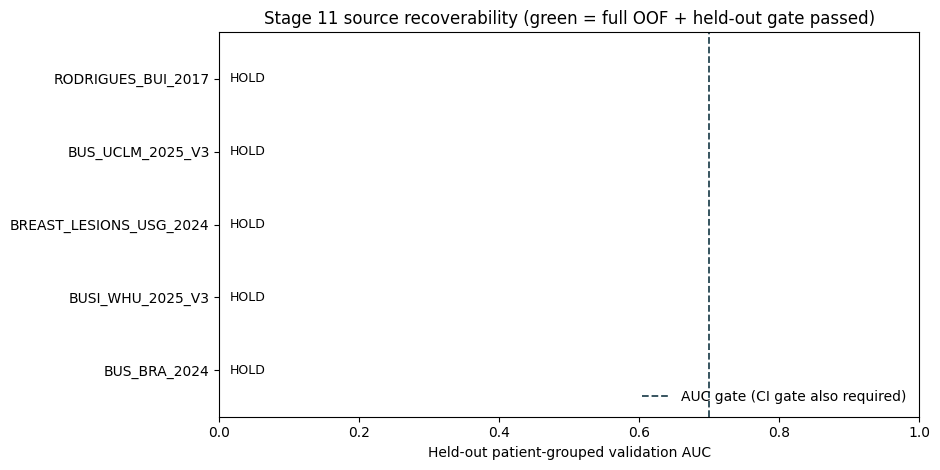


================ STAGE 11 DEVELOPMENT ACQUISITION AND SOURCE GATES COMPLETE ================
Development datasets with images / source axes / recoverable sources: 1 / 0 / 0
Recoverable sources: []
Locked-blind assets touched: False
Cross-domain edges / DDO2 fit / blind validation: False / False / False
Decision: COMPLETE_ACQUISITION_AUDIT_NO_RECOVERABLE_DEVELOPMENT_SOURCE_HOLD_STAGE12_AND_DDO2_FIT
Protocol seal: fc96bd4f61b41c0f64e5a24d8a270487acb25ad7c77d5b6865e9d9f4af59bbcd
Source summary hash: 2b907cc8ebbef7c6d3fc206b7c0a3067ad3d503594f2323d9f19f2a2c3a91af6
Final record hash: bc330e4389c36729427ca07c3ea1fb0993c5c3bc2126dcbfc2ca079e1cbb8889
Actual Stage 11 bytes: 9536029
Next step: REVIEW_STAGE11_HOLD_AND_UNAVAILABLE_CAUSES_WITHOUT_SUBSTITUTION_OR_BLIND_ACCESS


In [7]:
# @title 11-6. Seal the Stage 11 decision, report, figure, integrity manifest, and cleanup
import matplotlib.pyplot as plt

if REPLAY_MODE:
    final_record = verify_self_hashed_json(FINAL_RECORD_PATH, "final_record_sha256")
    output_manifest = pd.read_csv(OUTPUT_MANIFEST_PATH)
    for row in output_manifest.itertuples(index=False):
        path = PROJECT_ROOT / str(row.relative_path)
        assert path.is_file() and path.stat().st_size == int(row.size_bytes) and sha256_file(path) == str(row.sha256)
    actual_stage11_bytes = sum(path.stat().st_size for path in STAGE11_ROOT.rglob("*") if path.is_file())
else:
    plot = source_recoverability.copy()
    plot["validation_auc"] = pd.to_numeric(plot["validation_auc"], errors="coerce")
    plot["recoverable_bool"] = plot["recoverable"].map(as_bool)
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    y = np.arange(len(plot))
    values = plot["validation_auc"].fillna(0).to_numpy(float)
    colors = ["#2a9d8f" if passed else "#e76f51" for passed in plot["recoverable_bool"]]
    ax.barh(y, values, color=colors, alpha=0.9)
    ax.axvline(AUC_MINIMUM, color="#264653", linestyle="--", linewidth=1.3, label="AUC gate (CI gate also required)")
    ax.set_yticks(y, plot["source"].astype(str))
    ax.set_xlim(0, 1)
    ax.set_xlabel("Held-out patient-grouped validation AUC")
    ax.set_title("Stage 11 source recoverability (green = full OOF + held-out gate passed)")
    for index, value in enumerate(values):
        label = "HOLD" if not np.isfinite(plot.iloc[index]["validation_auc"]) else f"{value:.3f}"
        ax.text(min(value + 0.015, 0.96), index, label, va="center", fontsize=9)
    ax.legend(loc="lower right", frameon=False)
    fig.tight_layout()
    fig.savefig(FIGURE_PATH, dpi=180, bbox_inches="tight")
    plt.show()

    report = f"""# Stage 11 — Development Acquisition and Source Recoverability Report

## Decision

`{stage11_decision}`

## Scope and immutable parent

- Stage 10 final record: `{stage10_final['final_record_sha256']}`
- Stage 10 protocol seal: `{stage10_seal['seal_sha256']}`
- Stage 10 role registry: `{sha256_file(STAGE10_ROLE_PATH)}`
- Stage 11 protocol seal: `{protocol_seal['seal_sha256']}`
- Frozen role boundary: five development datasets may be accessed; three locked-blind datasets remain untouched.

## Realised development assets

- Datasets with harmonised eligible images: {acquired_manifest_datasets}/5
- Frozen source axes fitted: {source_axes_fitted}/5
- Recoverable sources: {len(recoverable_sources)}/5 — {', '.join(recoverable_sources) if recoverable_sources else 'none'}
- Holds/unavailable: `{json.dumps(hold_or_unavailable, ensure_ascii=False)}`

## Method

The same frozen ImageNet ResNet50 V2 2048D L2 representation used in Stage 8 was applied. Source axes use StandardScaler plus class-balanced L2 logistic regression. Every eligible source requires patient-grouped OOF AUC and a separate patient-disjoint held-out AUC of at least 0.70, with each patient-bootstrap lower 95% confidence bound strictly above 0.55. A dataset without defensible patient grouping is not treated as a source.

## Boundaries retained

- No cross-domain development edge was evaluated.
- No target model, threshold, feature direction, or role was tuned.
- No DDO2 coefficient was fitted.
- No locked-blind image, label, metadata file, archive, prediction, or result was accessed.
- Raw official archives/images remained in Colab temporary storage and were removed after completion.

## Next step

`{next_step}`
"""
    write_immutable_text(REPORT_PATH, report)

    tracked_files = [
        PROTOCOL_SEAL_PATH, PARENT_COMMITMENT_PATH, ACQUISITION_LEDGER_PATH, OFFICIAL_FILE_LEDGER_PATH,
        REQUEST_LOG_PATH, SCHEMA_AUDIT_PATH, DUPLICATE_AUDIT_PATH, VALIDATION_PATH,
        SOURCE_SUMMARY_PATH, PARTITION_INVENTORY_PATH, REPORT_PATH, FIGURE_PATH,
    ]
    tracked_files.extend(sorted(MANIFEST_ROOT.glob("*.csv")))
    tracked_files.extend(sorted(EMBEDDING_ROOT.glob("*.npz")))
    tracked_files.extend(sorted(AXIS_ROOT.glob("*_Frozen_Development_Validation_Manifest_v0.2.csv")))
    tracked_files.extend(sorted(AXIS_ROOT.glob("*_Frozen_Source_Axis_v0.2.npz")))
    tracked_files = sorted(set(path for path in tracked_files if path.is_file()), key=lambda path: str(path))
    output_manifest = pd.DataFrame([
        {"relative_path": str(path.relative_to(PROJECT_ROOT)), "size_bytes": path.stat().st_size, "sha256": sha256_file(path)}
        for path in tracked_files
    ])
    write_immutable_csv(OUTPUT_MANIFEST_PATH, output_manifest)
    output_manifest_hash = sha256_file(OUTPUT_MANIFEST_PATH)
    tracked_bytes = int(output_manifest["size_bytes"].sum() + OUTPUT_MANIFEST_PATH.stat().st_size)
    assert tracked_bytes <= MAXIMUM_NEW_STAGE11_BYTES, f"Stage 11 Drive cap exceeded: {tracked_bytes}"

    final_record = {
        "stage": "Stage11",
        "decision": stage11_decision,
        "scope": "DEVELOPMENT_ACQUISITION_AND_SOURCE_RECOVERABILITY_ONLY_NOT_TRANSFER_EDGES_NOT_DDO2_FIT_NOT_BLIND_VALIDATION",
        "parent_stage10_final_record_sha256": stage10_final["final_record_sha256"],
        "parent_stage10_protocol_seal_sha256": stage10_seal["seal_sha256"],
        "parent_role_registry_sha256": sha256_file(STAGE10_ROLE_PATH),
        "stage11_protocol_seal_sha256": protocol_seal["seal_sha256"],
        "notebook_source_sha256": notebook_source_hash,
        "authorised_development_datasets": list(AUTHORISED_DATASETS),
        "locked_blind_datasets": list(PROHIBITED_DATASETS),
        "development_datasets_with_harmonised_images": acquired_manifest_datasets,
        "source_axes_fitted": source_axes_fitted,
        "recoverable_sources": recoverable_sources,
        "recoverable_source_count": len(recoverable_sources),
        "minimum_recoverable_sources_needed_for_stage9_global_edge_count_gate": 3,
        "hold_or_unavailable_datasets": hold_or_unavailable,
        "locked_blind_assets_touched": False,
        "locked_blind_images_accessed": False,
        "locked_blind_labels_accessed": False,
        "cross_domain_edges_evaluated": False,
        "ddo2_coefficients_fitted": False,
        "blind_validation_performed": False,
        "raw_images_copied_to_drive": False,
        "independent_validity_checks_passed": True,
        "source_recoverability_summary_sha256": sha256_file(SOURCE_SUMMARY_PATH),
        "duplicate_audit_sha256": sha256_file(DUPLICATE_AUDIT_PATH),
        "validation_report_sha256": sha256_file(VALIDATION_PATH),
        "output_integrity_manifest_sha256": output_manifest_hash,
        "tracked_stage11_output_bytes_excluding_runtime_and_final_record": tracked_bytes,
        "maximum_new_stage11_bytes": MAXIMUM_NEW_STAGE11_BYTES,
        "next_step": next_step,
        "completed_utc": utc_now(),
    }
    final_record["final_record_sha256"] = sha256_json(final_record)
    write_immutable_json(FINAL_RECORD_PATH, final_record)
    runtime_state.update({
        "stage11_complete": True, "stage11_decision": stage11_decision,
        "locked_blind_assets_touched": False, "cross_domain_edges_evaluated": False,
        "ddo2_coefficients_fitted": False, "blind_validation_performed": False,
        "final_record_sha256": final_record["final_record_sha256"], "last_updated_utc": utc_now(),
    })
    atomic_json(RUNTIME_STATE_PATH, runtime_state)
    actual_stage11_bytes = sum(path.stat().st_size for path in STAGE11_ROOT.rglob("*") if path.is_file())

if TEMP_ROOT.exists():
    shutil.rmtree(TEMP_ROOT)
gc.collect()

print("\n================ STAGE 11 DEVELOPMENT ACQUISITION AND SOURCE GATES COMPLETE ================")
print("Development datasets with images / source axes / recoverable sources:",
      final_record["development_datasets_with_harmonised_images"], "/", final_record["source_axes_fitted"], "/", final_record["recoverable_source_count"])
print("Recoverable sources:", final_record["recoverable_sources"])
print("Locked-blind assets touched:", final_record["locked_blind_assets_touched"])
print("Cross-domain edges / DDO2 fit / blind validation:", final_record["cross_domain_edges_evaluated"], "/", final_record["ddo2_coefficients_fitted"], "/", final_record["blind_validation_performed"])
print("Decision:", final_record["decision"])
print("Protocol seal:", final_record["stage11_protocol_seal_sha256"])
print("Source summary hash:", final_record["source_recoverability_summary_sha256"])
print("Final record hash:", final_record["final_record_sha256"])
print("Actual Stage 11 bytes:", actual_stage11_bytes)
print("Next step:", final_record["next_step"])
